# Question 2: Data-Driven Discovery of a Discrete-Time Recurrence

**Objective**: Build predictors for univariate time series data, identify analytical recurrence patterns, and compare classical vs. deep learning approaches.

**Models Implemented**:
- Linear AR (Linear Autoregressive Model)
- MLP (Feedforward Neural Network)
- RNN (Vanilla Recurrent Neural Network)

## Setup and Imports

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import csv
import warnings
import os
import joblib
from tqdm import tqdm
from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

USERNAME = 'siddarth.g'

NORMALIZE_DATA = True

# --- Global variables for best model tracking ---
best_overall_val_loss = float('inf')
best_overall_model_info = {}
# ---

# Create a directory to save models
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

def add_username(ax=None):
    if ax is None:
        ax = plt.gca()
    ax.text(0.95, 0.95, USERNAME, ha='right', va='top', transform=ax.transAxes, fontsize=10, color='gray', alpha=0.7)

print("\n" + "="*60)
print("Setup Complete")
print(f"Data normalization: {'ENABLED' if NORMALIZE_DATA else 'DISABLED'}")
print("="*60)

Using device: cuda

Setup Complete
Data normalization: ENABLED


## 2.1 Dataset and Problem Setup

### Mathematical Background

We aim to discover a discrete-time recurrence relation of the form:

$$x_k = F_\theta(x_{k-1}, x_{k-2}, \ldots, x_{k-p})$$

where:
- $x_k$ is the value at time step $k$
- $p$ is the order of the recurrence (history length)
- $F_\theta$ is the mapping function parameterized by $\theta$

### Data Preparation Strategy

1. **Chronological Splits**: Use 70% train, 15% validation, 15% test to preserve temporal order
2. **History Length (p)**: Determine optimal lookback window
3. **Normalization**: Apply StandardScaler based on training statistics only
4. **Supervised Pairs**: Create $(h_k \rightarrow x_k)$ where $h_k = [x_{k-p}, \ldots, x_{k-1}]$

Loading dataset...
Dataset shape: (54000,)
Total timesteps: 54000
Value range: [-0.9996, 0.9997]
Mean: -0.0007, Std: 0.1613


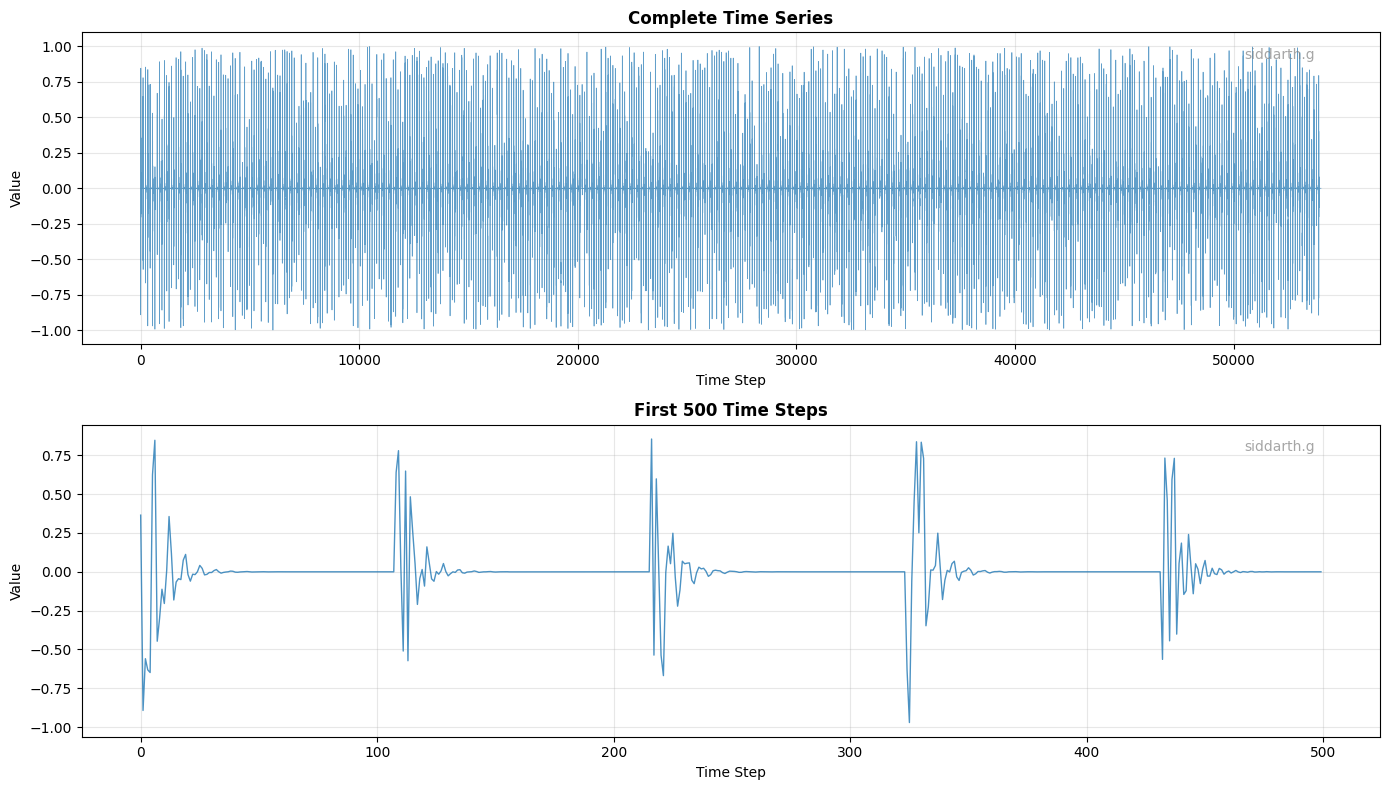


Baseline MAE (predicting 0): 0.0493
Baseline MSE (predicting 0): 0.0260


In [88]:
def load_data(file_path='recurrence_timeseries.csv'):
    """
    Load time series data from CSV file.
    
    Returns:
        np.ndarray: 1D array of time series values
    """
    print("Loading dataset...")
    df = pd.read_csv(file_path)
    data = df.values.flatten().astype(np.float32)
    
    print(f"Dataset shape: {data.shape}")
    print(f"Total timesteps: {len(data)}")
    print(f"Value range: [{data.min():.4f}, {data.max():.4f}]")
    print(f"Mean: {data.mean():.4f}, Std: {data.std():.4f}")
    
    return data

# Load the data
data = load_data()

# Visualize the raw time series
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full series
axes[0].plot(data, linewidth=0.5, alpha=0.7)
axes[0].set_title('Complete Time Series', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)
add_username(axes[0])

# First 500 points for detail
axes[1].plot(data[:500], linewidth=1, alpha=0.8)
axes[1].set_title('First 500 Time Steps', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Value')
axes[1].grid(True, alpha=0.3)
add_username(axes[1])

plt.tight_layout()
plt.show()

print("\n" + "="*60)

# Let's check baseline loss
# Loss when it is predicted to be 0 all the time is just the norm of the data
baseline_mae = np.mean(np.abs(data))
baseline_mse = np.mean(data**2)
print(f"Baseline MAE (predicting 0): {baseline_mae:.4f}")
print(f"Baseline MSE (predicting 0): {baseline_mse:.4f}")

### Create Supervised Learning Pairs

Transform the time series into supervised learning format:
$$\{(h_k, x_k)\}_{k=p}^{T}$$

where $h_k = [x_{k-p}, x_{k-p+1}, \ldots, x_{k-1}]$

In [89]:
def create_sequences(data, history_length):
    X, y = [], []
    
    for i in range(history_length, len(data)):
        X.append(data[i-history_length:i])
        y.append(data[i])
    
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

def create_splits(X, y, train_ratio=0.7, val_ratio=0.15):
    n_samples = len(X)
    train_end = int(n_samples * train_ratio)
    val_end = int(n_samples * (train_ratio + val_ratio))
    
    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]
    
    print(f"Data Split Summary:")
    print(f"  Training:   {len(X_train):6d} samples ({len(X_train)/n_samples*100:.1f}%)")
    print(f"  Validation: {len(X_val):6d} samples ({len(X_val)/n_samples*100:.1f}%)")
    print(f"  Test:       {len(X_test):6d} samples ({len(X_test)/n_samples*100:.1f}%)")
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

def prepare_data_for_history(data, history_length, normalize=True):
    X, y = create_sequences(data, history_length)
    
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = create_splits(X, y)
    
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    
    scaler_X.fit(X_train)
    scaler_y.fit(y_train.reshape(-1, 1))
    
    if normalize:
        X_train_scaled = scaler_X.transform(X_train).astype(np.float32)
        X_val_scaled = scaler_X.transform(X_val).astype(np.float32)
        X_test_scaled = scaler_X.transform(X_test).astype(np.float32)

        y_train_scaled = scaler_y.transform(y_train.reshape(-1, 1)).ravel().astype(np.float32)
        y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).ravel().astype(np.float32)
        y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel().astype(np.float32)
    else:
        X_train_scaled = X_train.copy()
        X_val_scaled = X_val.copy()
        X_test_scaled = X_test.copy()
        
        y_train_scaled = y_train.copy()
        y_val_scaled = y_val.copy()
        y_test_scaled = y_test.copy()
    
    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'X_train_scaled': X_train_scaled, 'y_train_scaled': y_train_scaled,
        'X_val_scaled': X_val_scaled, 'y_val_scaled': y_val_scaled,
        'X_test_scaled': X_test_scaled, 'y_test_scaled': y_test_scaled,
        'scaler_X': scaler_X,
        'scaler_y': scaler_y
    }

def inverse_transform_and_compute_loss(outputs, targets, scaler, criterion):
    """
    Inverse transforms model outputs and targets before computing loss.
    
    Args:
        outputs (torch.Tensor): Scaled predictions from the model.
        targets (torch.Tensor): Scaled ground truth values.
        scaler (StandardScaler): The scaler object for the target variable.
        criterion (nn.Module): The loss function.
        
    Returns:
        torch.Tensor: The computed loss on the original data scale.
    """
    # Detach from graph, move to CPU, and convert to numpy for inverse scaling
    unscaled_outputs_np = scaler.inverse_transform(outputs.detach().cpu().numpy().reshape(-1, 1))
    unscaled_targets_np = scaler.inverse_transform(targets.detach().cpu().numpy().reshape(-1, 1))
    
    # Convert back to tensors for loss calculation
    unscaled_outputs = torch.from_numpy(unscaled_outputs_np).to(outputs.device).float().squeeze()
    unscaled_targets = torch.from_numpy(unscaled_targets_np).to(targets.device).float().squeeze()
    
    return criterion(unscaled_outputs, unscaled_targets)

HISTORY_LENGTHS = [5, 10, 25, 50, 100]

print("="*60)
print("PREPARING DATA FOR DIFFERENT HISTORY LENGTHS")
print("="*60)

data_configs = {}
for hist_len in HISTORY_LENGTHS:
    print(f"\nHistory length: {hist_len}")
    data_configs[hist_len] = prepare_data_for_history(data, hist_len, normalize=NORMALIZE_DATA)
    if NORMALIZE_DATA:
        print(f"  Normalization: Applied")
    else:
        print(f"  Normalization: Skipped")

print("\n" + "="*60)

PREPARING DATA FOR DIFFERENT HISTORY LENGTHS

History length: 5
Data Split Summary:
  Training:    37796 samples (70.0%)
  Validation:   8099 samples (15.0%)
  Test:         8100 samples (15.0%)
  Normalization: Applied

History length: 10
Data Split Summary:
  Training:    37793 samples (70.0%)
  Validation:   8098 samples (15.0%)
  Test:         8099 samples (15.0%)
  Normalization: Applied

History length: 25
Data Split Summary:
  Training:    37782 samples (70.0%)
  Validation:   8096 samples (15.0%)
  Test:         8097 samples (15.0%)
  Normalization: Applied

History length: 50
Data Split Summary:
  Training:    37765 samples (70.0%)
  Validation:   8092 samples (15.0%)
  Test:         8093 samples (15.0%)
  Normalization: Applied

History length: 100
Data Split Summary:
  Training:    37730 samples (70.0%)
  Validation:   8085 samples (15.0%)
  Test:         8085 samples (15.0%)
  Normalization: Applied



In [90]:
def plot_time_series_predictions(model, model_type, data_dict, data, history_length, model_name='Model'):
    """
    Plot original vs predicted time series data in a 2x2 grid.
    
    Args:
        model: The trained model
        model_type: 'linear_ar', 'mlp', or 'rnn'
        data_dict: Dictionary containing train/val/test splits and scalers
        data: Original full time series data
        history_length: History length used by the model
        model_name: Name for the plot title
    """
    # Get all data (scaled versions for neural nets)
    if model_type == 'linear_ar':
        X_all = np.concatenate([data_dict['X_train'], data_dict['X_val'], data_dict['X_test']], axis=0)
        y_all = np.concatenate([data_dict['y_train'], data_dict['y_val'], data_dict['y_test']], axis=0)
        predictions = model.predict(X_all)
    else:  # MLP or RNN
        X_all = np.concatenate([data_dict['X_train_scaled'], data_dict['X_val_scaled'], data_dict['X_test_scaled']], axis=0)
        y_all = np.concatenate([data_dict['y_train'], data_dict['y_val'], data_dict['y_test']], axis=0)
        scaler_y = data_dict['scaler_y']
        predictions = model.predict(X_all, scaler_y)
    
    # The predictions align with data[history_length:] since we need history to predict
    original_full = data[history_length:]
    predicted_full = predictions
    
    # Find middle 250 elements
    mid_point = len(original_full) // 2
    start_idx = max(0, mid_point - 125)
    end_idx = min(len(original_full), start_idx + 250)
    
    original_slice = original_full[start_idx:end_idx]
    predicted_slice = predicted_full[start_idx:end_idx]
    
    # Create 2x2 plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Top-left: Full original data
    ax = axes[0, 0]
    ax.plot(range(history_length, len(data)), original_full, linewidth=0.8, alpha=0.7, label='Original')
    ax.set_title(f'{model_name} - Full Original Time Series', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    ax.legend()
    add_username(ax)
    
    # Top-right: Full predicted data
    ax = axes[0, 1]
    ax.plot(range(history_length, len(data)), predicted_full, linewidth=0.8, alpha=0.7, label='Predicted', color='orange')
    ax.set_title(f'{model_name} - Full Predicted Time Series', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    ax.legend()
    add_username(ax)
    
    # Bottom-left: Middle slice original
    ax = axes[1, 0]
    ax.plot(range(start_idx, end_idx), original_slice, linewidth=1.5, alpha=0.7, label='Original')
    ax.set_title(f'{model_name} - Middle 250 Steps (Original)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Step (offset)')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    ax.legend()
    add_username(ax)
    
    # Bottom-right: Middle slice predicted overlaid with original
    ax = axes[1, 1]
    ax.plot(range(start_idx, end_idx), original_slice, linewidth=1.5, alpha=0.7, label='Original', color='blue')
    ax.plot(range(start_idx, end_idx), predicted_slice, linewidth=1.5, alpha=0.7, label='Predicted', color='orange', linestyle='--')
    ax.set_title(f'{model_name} - Middle 250 Steps (Comparison)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Step (offset)')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    ax.legend()
    add_username(ax)
    
    plt.tight_layout()
    plt.show()
    
    # Compute and print metrics for the full prediction
    mse = mean_squared_error(original_full, predicted_full)
    mae = mean_absolute_error(original_full, predicted_full)
    print(f"\n{model_name} - Full Series Prediction Metrics:")
    print(f"  MSE: {mse:.6f}")
    print(f"  MAE: {mae:.6f}")
    print(f"  Predicted {len(predicted_full)} time steps (excluding initial {history_length} history)")


LINEAR AR MODEL - HYPERPARAMETER SEARCH

Training Linear AR with history length: 5
  Train MSE: 0.025455, Val MSE: 0.026332, Test MSE: 0.024921
  Parameters: 6
  >> New best model found! Saved to saved_models/best_linear_ar_h5.joblib
  AR Coefficients:
    phi_1 = 0.029109
    phi_2 = -0.073241
    phi_3 = -0.054396
    phi_4 = -0.073898
    phi_5 = -0.080696
  Intercept = -0.000794

Training Linear AR with history length: 10
  Train MSE: 0.024418, Val MSE: 0.025365, Test MSE: 0.023926
  Parameters: 11
  >> New best model found! Saved to saved_models/best_linear_ar_h10.joblib
  AR Coefficients:
    phi_1 = 0.031906
    phi_2 = -0.041071
    phi_3 = -0.040610
    phi_4 = -0.064195
    phi_5 = -0.078595
    phi_6 = 0.090191
    phi_7 = 0.154485
    phi_8 = -0.076108
    phi_9 = -0.023098
    phi_10 = -0.007016
  Intercept = -0.000694

Training Linear AR with history length: 25
  Train MSE: 0.024456, Val MSE: 0.025332, Test MSE: 0.023775
  Parameters: 26
  >> New best model found! Saved t

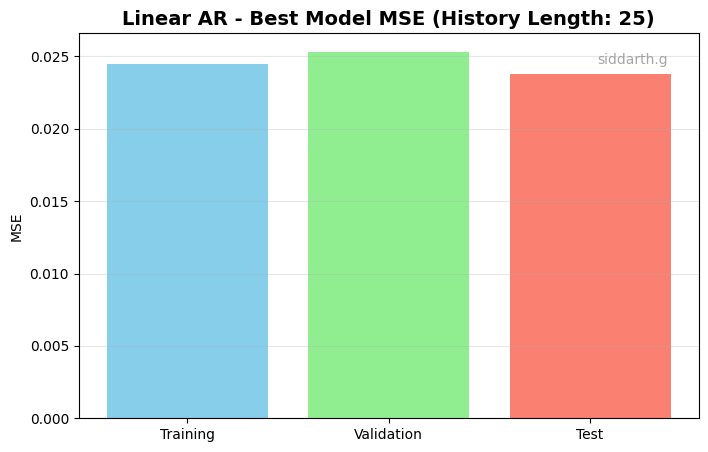


LINEAR AR - TIME SERIES PREDICTION VISUALIZATION


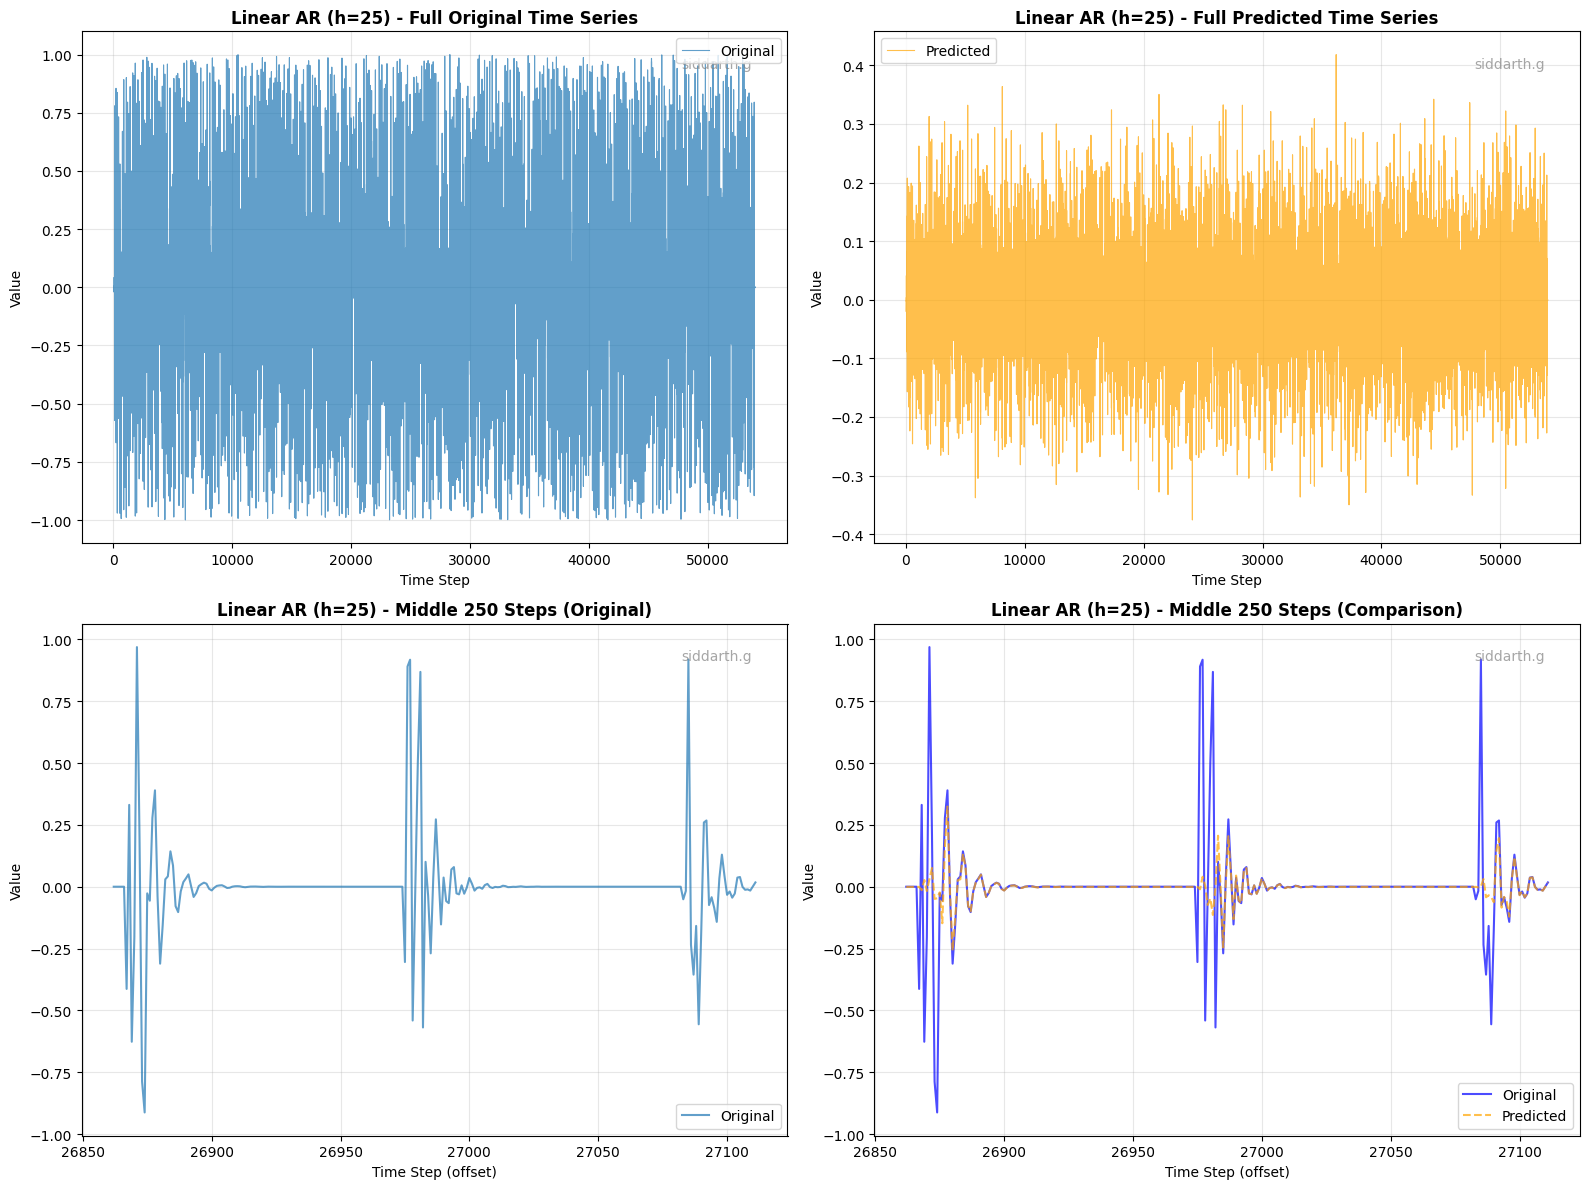


Linear AR (h=25) - Full Series Prediction Metrics:
  MSE: 0.024486
  MAE: 0.039724
  Predicted 53975 time steps (excluding initial 25 history)



In [91]:
class LinearARPredictor:
    def __init__(self):
        self.model = LinearRegression()
        self.ar_coefs = None
        self.intercept = None
        
    def fit(self, X_train, y_train):
        self.model.fit(X_train, y_train)
        self.ar_coefs = self.model.coef_[::-1]
        self.intercept = self.model.intercept_
        return self
    
    def predict(self, X):
        return self.model.predict(X)

def evaluate_simple_model(model, X, y):
    predictions = model.predict(X)
    mse = mean_squared_error(y, predictions)
    mae = mean_absolute_error(y, predictions)
    return mse, mae

def count_parameters(model, model_type):
    """Count the number of trainable parameters in a model."""
    if model_type == 'linear_ar':
        return len(model.model.coef_) + 1  # coefficients + intercept
    else:  # MLP or RNN (PyTorch models)
        return sum(p.numel() for p in model.parameters() if p.requires_grad)

csv_file = 'model_losses.csv'
with open(csv_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Model', 'History_Length', 'Train_Loss', 'Val_Loss', 'Test_Loss', 'Num_Parameters'])

print("="*60)
print("LINEAR AR MODEL - HYPERPARAMETER SEARCH")
print("="*60)

linear_ar_results = []

for hist_len in HISTORY_LENGTHS:
    print(f"\nTraining Linear AR with history length: {hist_len}")
    
    data_dict = data_configs[hist_len]
    X_train = data_dict['X_train']
    y_train = data_dict['y_train']
    X_val = data_dict['X_val']
    y_val = data_dict['y_val']
    X_test = data_dict['X_test']
    y_test = data_dict['y_test']
    
    model = LinearARPredictor()
    model.fit(X_train, y_train)
    
    train_mse, train_mae = evaluate_simple_model(model, X_train, y_train)
    val_mse, val_mae = evaluate_simple_model(model, X_val, y_val)
    test_mse, test_mae = evaluate_simple_model(model, X_test, y_test)
    
    num_params = count_parameters(model, 'linear_ar')
    
    print(f"  Train MSE: {train_mse:.6f}, Val MSE: {val_mse:.6f}, Test MSE: {test_mse:.6f}")
    print(f"  Parameters: {num_params}")
    
    with open(csv_file, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Linear_AR', hist_len, train_mse, val_mse, test_mse, num_params])
    
    if val_mse < best_overall_val_loss:
        best_overall_val_loss = val_mse
        
        # Remove old best model if it exists
        if 'path' in best_overall_model_info and os.path.exists(best_overall_model_info['path']):
            os.remove(best_overall_model_info['path'])
            
        model_path = f"saved_models/best_linear_ar_h{hist_len}.joblib"
        joblib.dump(model.model, model_path)
        
        best_overall_model_info = {
            'type': 'Linear_AR',
            'path': model_path,
            'history_length': hist_len,
            'val_loss': val_mse
        }
        print(f"  >> New best model found! Saved to {model_path}")

    print(f"  AR Coefficients:")
    for i, coef in enumerate(model.ar_coefs, 1):
        print(f"    phi_{i} = {coef:.6f}")
    print(f"  Intercept = {model.intercept:.6f}")
    
    linear_ar_results.append({
        'model': model,
        'history_length': hist_len,
        'val_mse': val_mse,
        'val_mae': val_mae,
        'train_mse': train_mse,
        'test_mse': test_mse
    })

print("\n" + "="*60)
print("LINEAR AR RESULTS ACROSS HISTORY LENGTHS")
print("="*60)
print(f"{'History':<10} {'Train MSE':<12} {'Val MSE':<12} {'Test MSE':<12}")
print("-"*60)
for result in sorted(linear_ar_results, key=lambda x: x['val_mse']):
    print(f"{result['history_length']:<10} {result['train_mse']:<12.6f} {result['val_mse']:<12.6f} {result['test_mse']:<12.6f}")
print("="*60)

best_linear_ar = min(linear_ar_results, key=lambda x: x['val_mse'])
linear_ar_model = best_linear_ar['model']
best_linear_ar_history = best_linear_ar['history_length']

print(f"\nBest Linear AR configuration:")
print(f"  History length: {best_linear_ar_history}")
print(f"  Validation MSE: {best_linear_ar['val_mse']:.6f}")

expression_terms = [f"{coef:.6f} * x_(k-{i})" for i, coef in enumerate(linear_ar_model.ar_coefs, 1)]
expression = " + ".join(expression_terms)
expression = f"x_k = {expression} + {linear_ar_model.intercept:.6f}"
print(f"\nBest Model Analytical Expression:\n  {expression}")

# Plot MSE comparison for best model only
data_dict = data_configs[best_linear_ar_history]
X_train_best = data_dict['X_train']
y_train_best = data_dict['y_train']
X_val_best = data_dict['X_val']
y_val_best = data_dict['y_val']
X_test_best = data_dict['X_test']
y_test_best = data_dict['y_test']

datasets = ['Training', 'Validation', 'Test']
mse_values = []
for X, y in [(X_train_best, y_train_best), (X_val_best, y_val_best), (X_test_best, y_test_best)]:
    mse, _ = evaluate_simple_model(linear_ar_model, X, y)
    mse_values.append(mse)

plt.figure(figsize=(8, 5))
plt.bar(datasets, mse_values, color=['skyblue', 'lightgreen', 'salmon'])
plt.title(f'Linear AR - Best Model MSE (History Length: {best_linear_ar_history})', fontsize=14, fontweight='bold')
plt.ylabel('MSE')
plt.grid(axis='y', alpha=0.3)
add_username()
plt.show()

# Plot time series predictions for best Linear AR model
print("\n" + "="*60)
print("LINEAR AR - TIME SERIES PREDICTION VISUALIZATION")
print("="*60)
data_dict_best_linear = data_configs[best_linear_ar_history]
plot_time_series_predictions(
    linear_ar_model, 
    'linear_ar', 
    data_dict_best_linear, 
    data, 
    best_linear_ar_history,
    f'Linear AR (h={best_linear_ar_history})'
)

print("\n" + "="*60)

### Model 3: RNN (Recurrent Neural Network)

**Vanilla RNN Equations**:

$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$

$\hat{y}_t = W_{hy} h_t + b_y$

**Advantages**: Captures sequential patterns, processes temporal dependencies

### Model 2: MLP (Multi-Layer Perceptron)

**MLP Architecture**:
- Feedforward neural network with configurable hidden layers
- ReLU activation functions for non-linearity
- Learns complex non-linear mappings from history to next value

**Advantages**: Captures non-linear patterns, flexible architecture

In [92]:
class MLPModel(nn.Module):
    def __init__(self, input_size, hidden_layers=(64, 32)):
        super(MLPModel, self).__init__()
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, 1))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze()

MLP MODEL - BAYESIAN HYPERPARAMETER OPTIMIZATION

Parameter space:
  History lengths: [5, 10, 25, 50, 100]
  Architectures: [(64,), (128, 64)]
  Learning rates: [5e-06, 1e-05, 2.5e-05, 5e-05]
  Batch size (fixed): 64
  Total combinations: 40
  Trials to run: 10

Starting Bayesian optimization for MLP (10 iterations)...

[Trial 1] Testing: history=50, arch=(64,), lr=0.00005, batch=64


  Results: Train=0.023977, Val=0.025359, Test=0.023645, Epochs=200
  Parameters: 3329


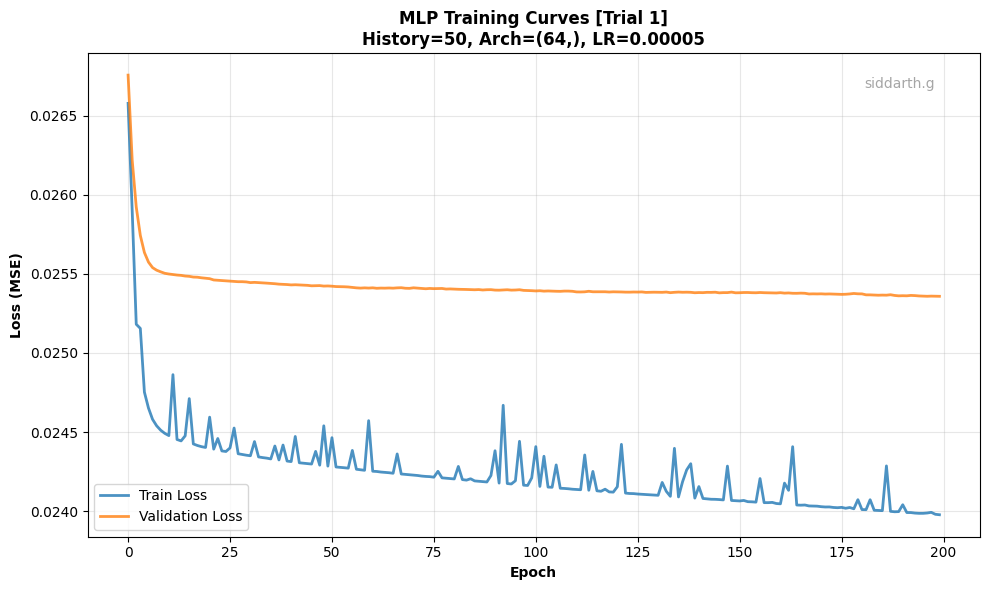


[Trial 2] Testing: history=25, arch=(64,), lr=0.00001, batch=64


  Results: Train=0.024393, Val=0.025308, Test=0.023859, Epochs=172
  Parameters: 1729
  >> New best model! Val loss: 0.025308


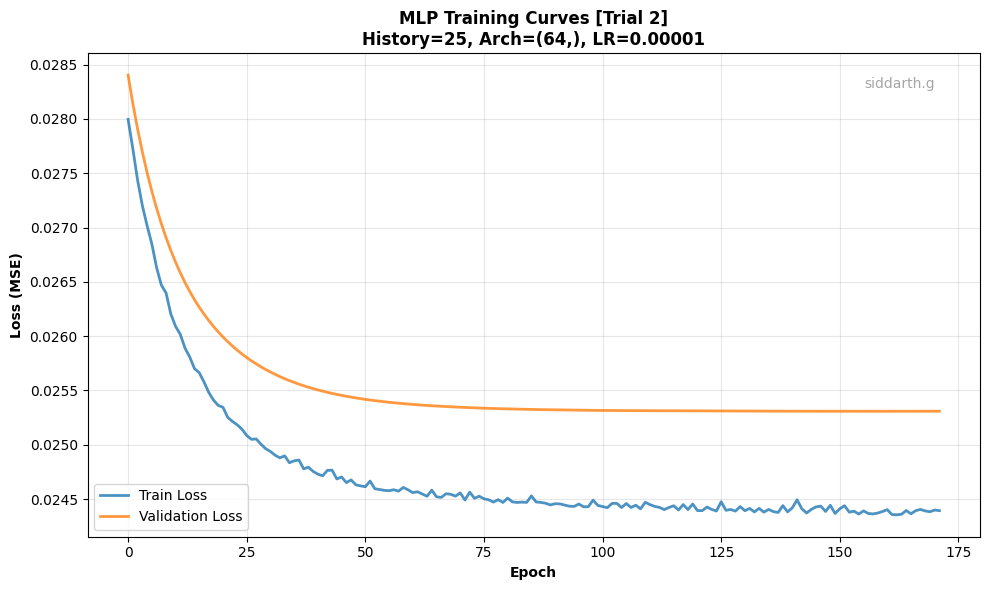


[Trial 3] Testing: history=25, arch=(64,), lr=0.00001, batch=64


  Results: Train=0.024346, Val=0.025398, Test=0.023756, Epochs=200
  Parameters: 1729


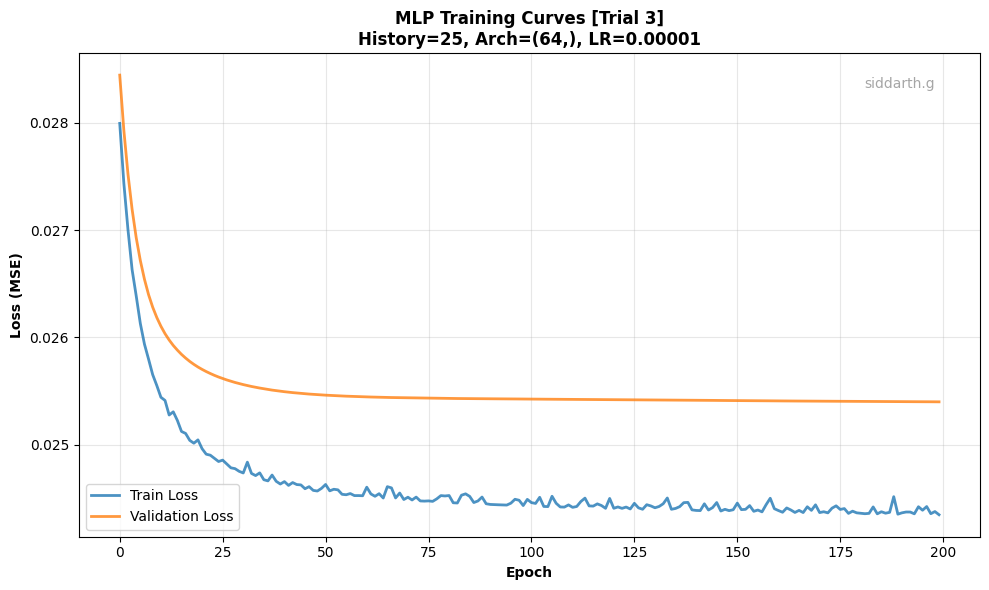


[Trial 4] Testing: history=50, arch=(64,), lr=0.00003, batch=64


  Results: Train=0.024223, Val=0.025482, Test=0.023661, Epochs=138
  Parameters: 3329


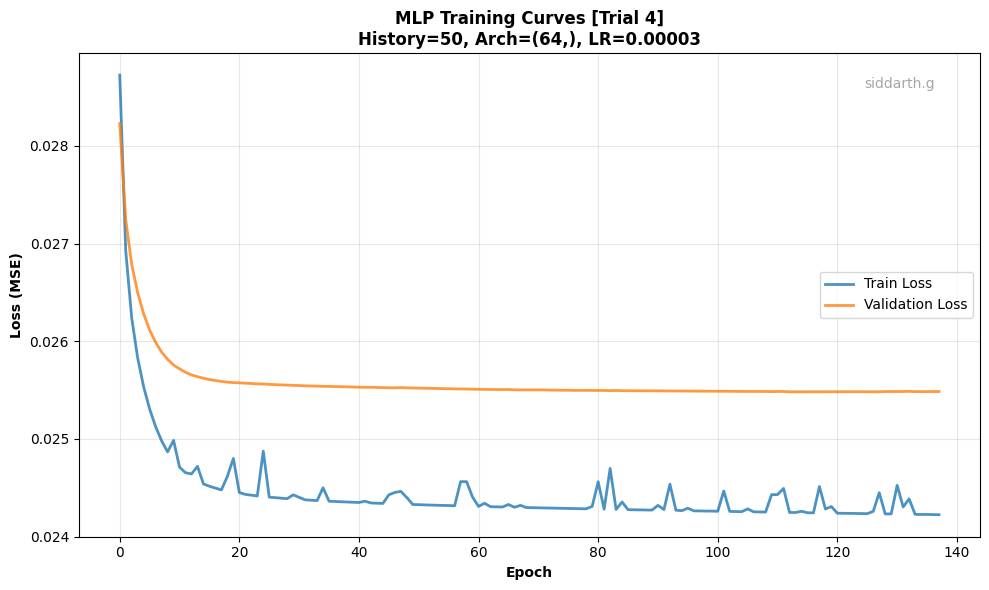


[Trial 5] Testing: history=100, arch=(64,), lr=0.00005, batch=64


  Results: Train=0.024211, Val=0.025561, Test=0.023601, Epochs=70
  Parameters: 6529


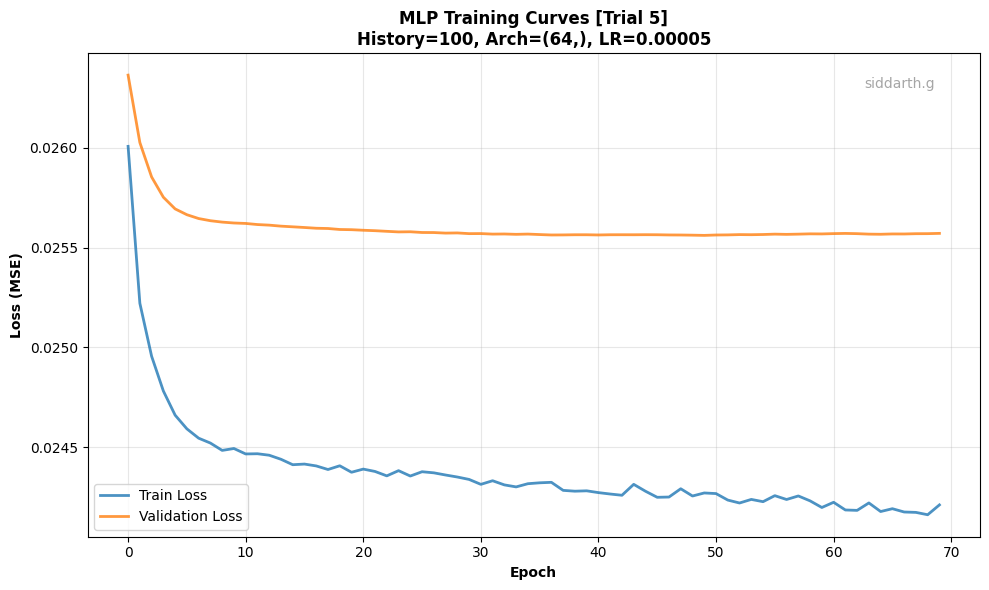


[Trial 6] Testing: history=50, arch=(128, 64), lr=0.00001, batch=64


  Results: Train=0.024065, Val=0.025261, Test=0.023398, Epochs=200
  Parameters: 14849
  >> New best model! Val loss: 0.025261


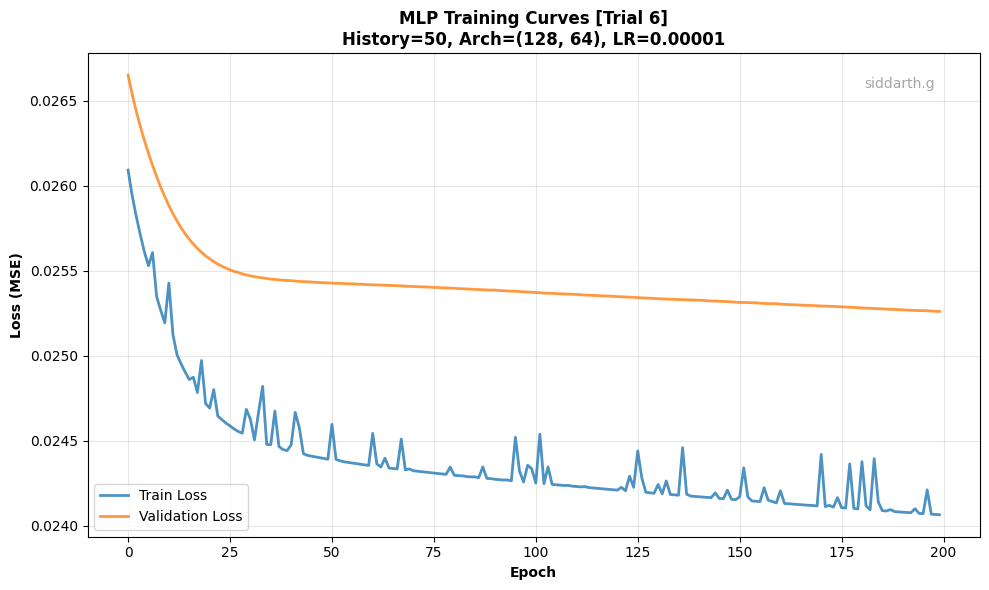


[Trial 7] Testing: history=5, arch=(128, 64), lr=0.00001, batch=64


  Results: Train=0.024585, Val=0.025758, Test=0.024606, Epochs=200
  Parameters: 9089


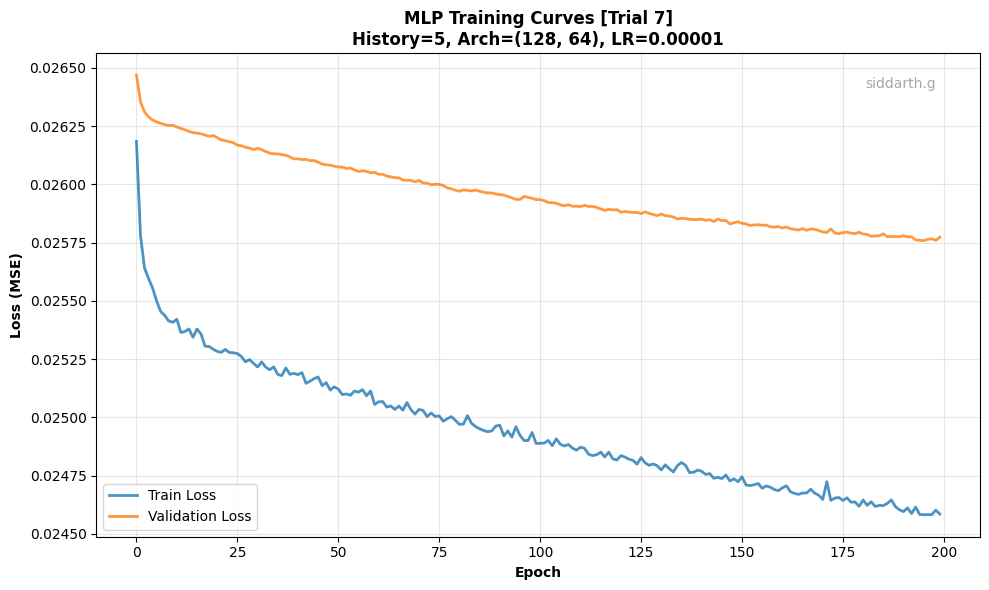


[Trial 8] Testing: history=5, arch=(128, 64), lr=0.00001, batch=64


  Results: Train=0.024832, Val=0.025994, Test=0.024553, Epochs=200
  Parameters: 9089


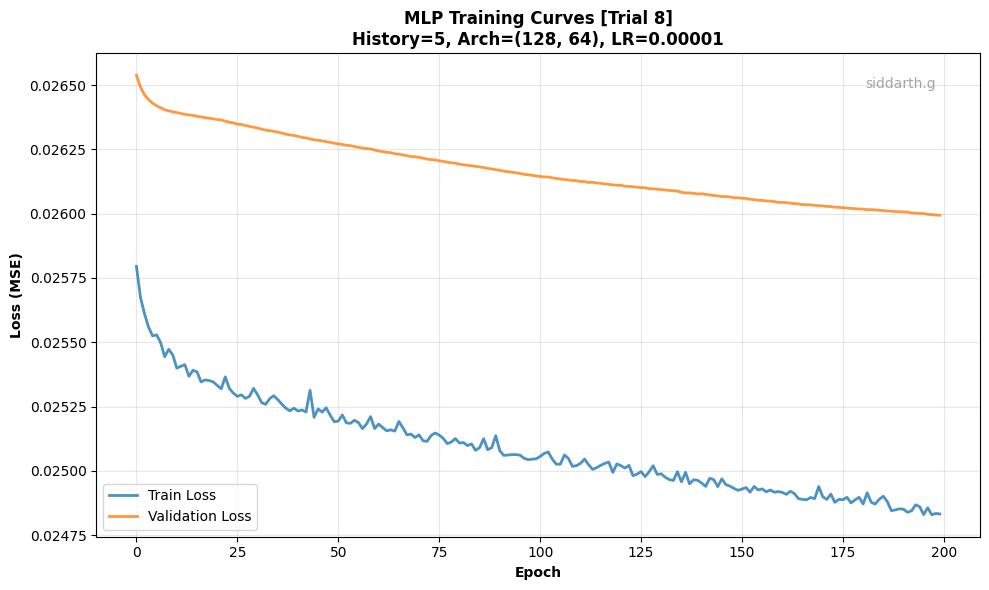


[Trial 9] Testing: history=5, arch=(128, 64), lr=0.00001, batch=64


  Results: Train=0.024502, Val=0.025837, Test=0.024525, Epochs=200
  Parameters: 9089


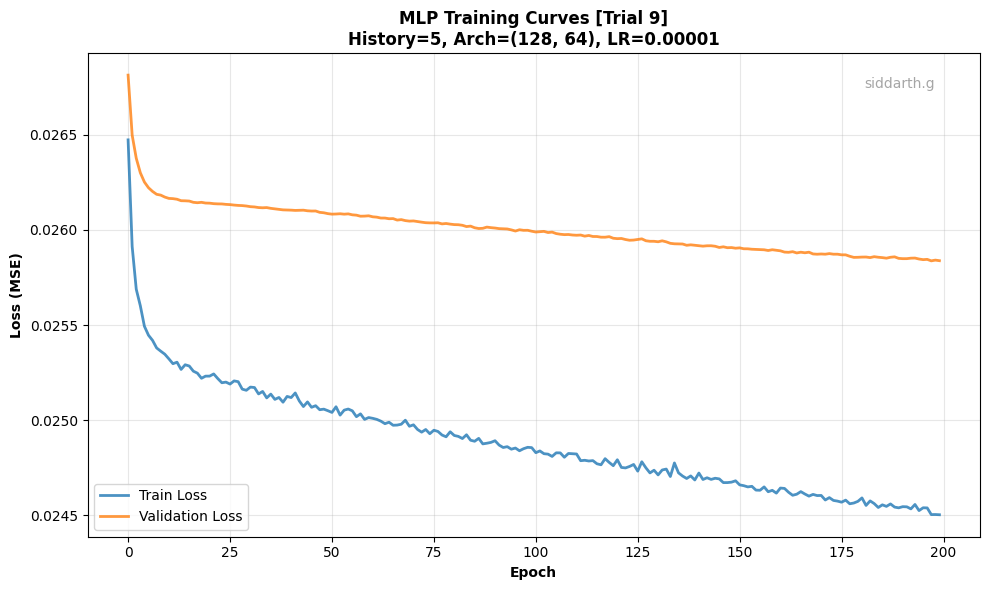


[Trial 10] Testing: history=100, arch=(64,), lr=0.00005, batch=64


  Results: Train=0.024191, Val=0.025661, Test=0.023540, Epochs=69
  Parameters: 6529


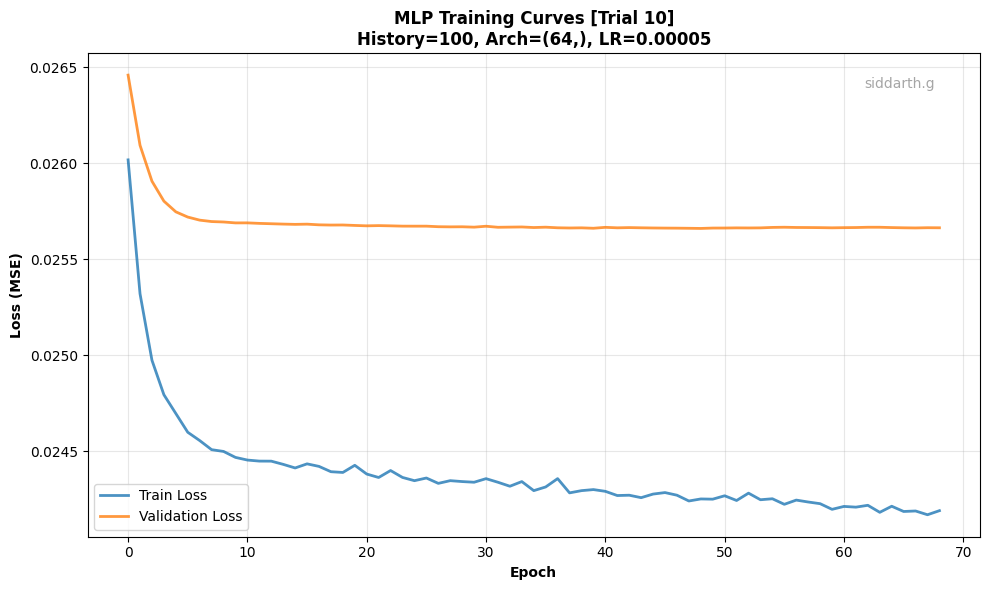


MLP BAYESIAN OPTIMIZATION COMPLETE

Best hyperparameters found:
  History length: 50
  Architecture: 1
  Learning rate: 0.00001
  Batch size (fixed): 64
  Best validation loss: 0.025261

MLP RESULTS - TOP 10 CONFIGURATIONS
History    Architecture         LR         Batch    Train Loss   Val Loss     Test Loss   
----------------------------------------------------------------------------------------------------
50         (128, 64)            0.00001    64       0.024065     0.025261     0.023398    
25         (64,)                0.00001    64       0.024393     0.025308     0.023859    
50         (64,)                0.00005    64       0.023977     0.025359     0.023645    
25         (64,)                0.00001    64       0.024346     0.025398     0.023756    
50         (64,)                0.00003    64       0.024223     0.025482     0.023661    
100        (64,)                0.00005    64       0.024211     0.025561     0.023601    
100        (64,)                0.0000

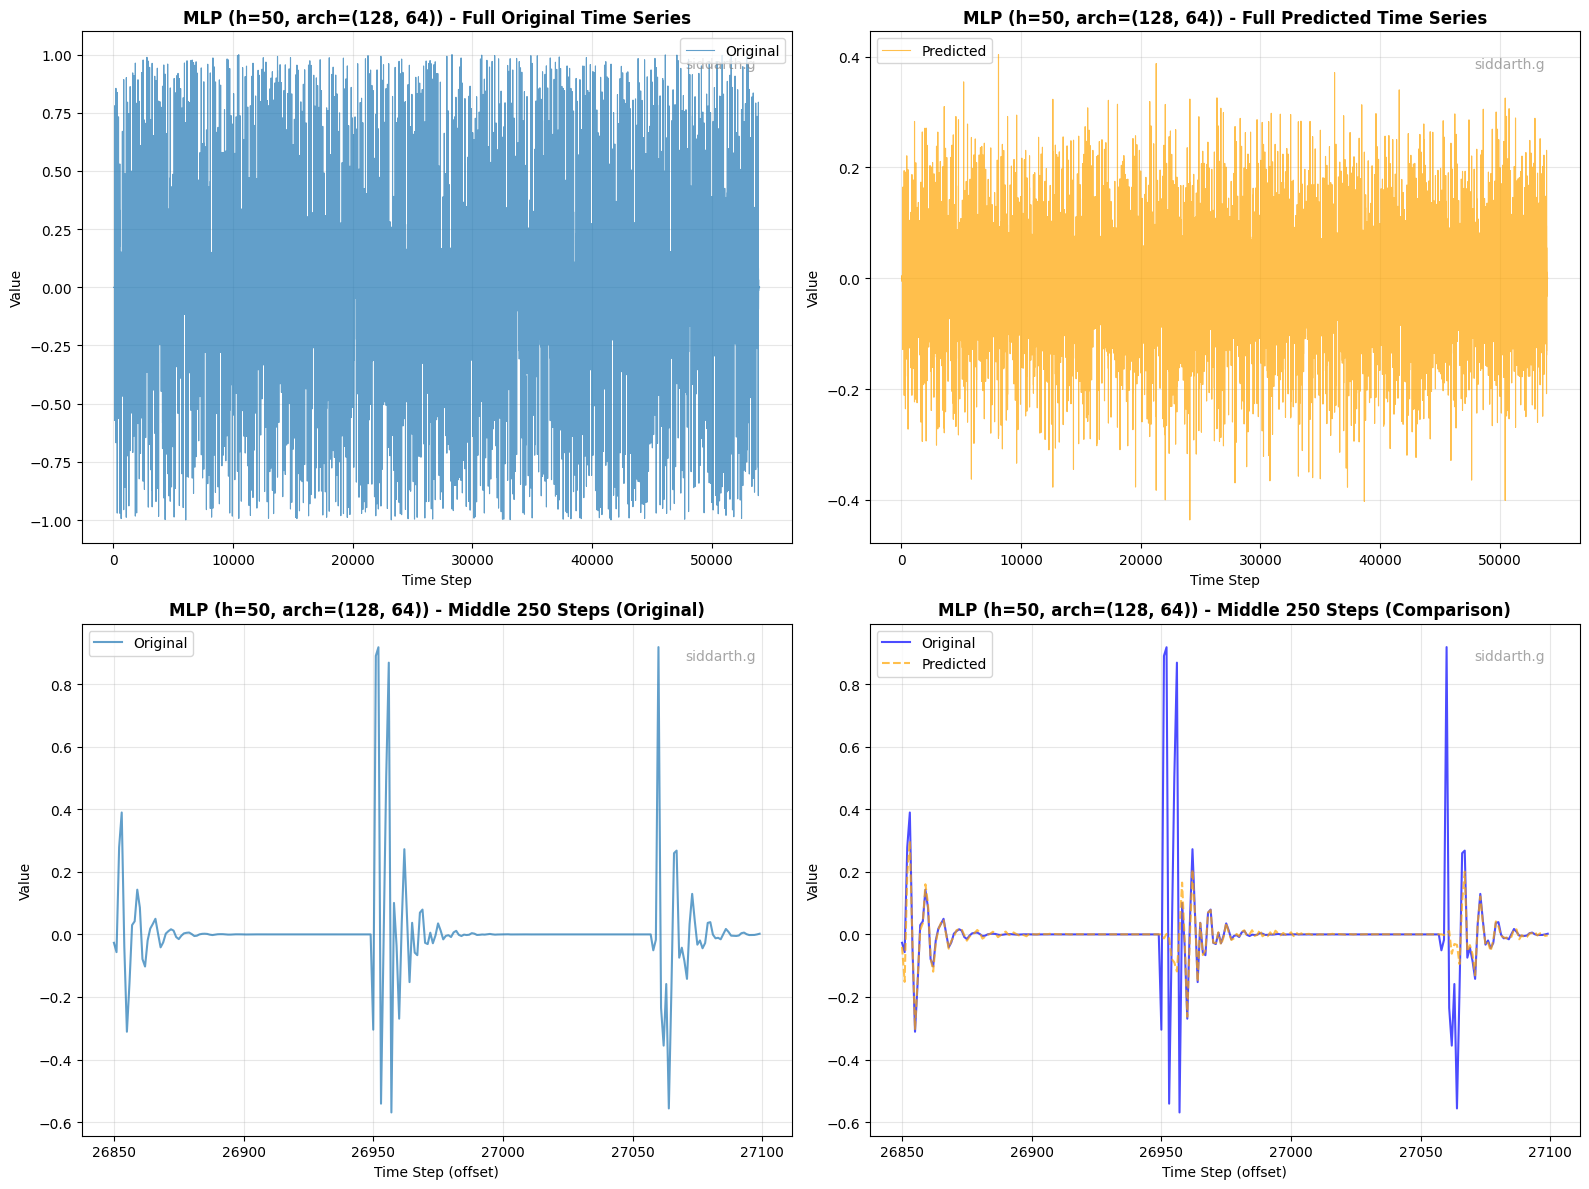


MLP (h=50, arch=(128, 64)) - Full Series Prediction Metrics:
  MSE: 0.024167
  MAE: 0.040015
  Predicted 53950 time steps (excluding initial 50 history)



In [93]:
class MLPPredictor:
    def __init__(self, input_size, hidden_layers=(64, 32), learning_rate=0.001):
        self.model = MLPModel(input_size, hidden_layers).to(device)
        self.hidden_layers = hidden_layers
        self.learning_rate = learning_rate
        self.train_losses = []
        self.val_losses = []

    def fit(self, X_train, y_train, X_val, y_val, scaler_y, max_iter=200, batch_size=64):
        X_train_t = torch.FloatTensor(X_train)
        y_train_t = torch.FloatTensor(y_train)
        X_val_t = torch.FloatTensor(X_val).to(device)
        y_val_t = torch.FloatTensor(y_val).to(device)

        train_dataset = TensorDataset(X_train_t, y_train_t)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

        criterion = nn.MSELoss()
        optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)

        best_val_loss = float('inf')
        best_model_state = None
        patience = 20
        patience_counter = 0

        self.train_losses = []
        self.val_losses = []

        epoch_pbar = tqdm(range(max_iter), desc="MLP Training", leave=False)
        for epoch in epoch_pbar:
            self.model.train()
            train_batch_losses = []

            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad()
                outputs = self.model(batch_X)
                
                # Compute loss on scaled data for backpropagation
                loss = criterion(outputs.squeeze(), batch_y)
                
                loss.backward()
                optimizer.step()

                # Compute loss on original scale for reporting
                reporting_loss = inverse_transform_and_compute_loss(outputs, batch_y, scaler_y, criterion)
                train_batch_losses.append(reporting_loss.item())

            avg_train_loss = np.mean(train_batch_losses)
            self.train_losses.append(avg_train_loss)

            self.model.eval()
            with torch.no_grad():
                val_outputs = self.model(X_val_t)
                # Compute validation loss on original scale
                val_loss = inverse_transform_and_compute_loss(val_outputs, y_val_t, scaler_y, criterion).item()
            self.val_losses.append(val_loss)
            
            epoch_pbar.set_postfix({'train_loss': avg_train_loss, 'val_loss': val_loss})

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = self.model.state_dict().copy()
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                break
        
        epoch_pbar.close()
        if best_model_state is not None:
            self.model.load_state_dict(best_model_state)

        return self, best_val_loss

    def predict(self, X, scaler_y):
        self.model.eval()
        with torch.no_grad():
            X_t = torch.FloatTensor(X).to(device)
            scaled_predictions = self.model(X_t)
            # Inverse transform predictions to original scale
            unscaled_predictions = scaler_y.inverse_transform(scaled_predictions.cpu().numpy().reshape(-1, 1)).flatten()
            return unscaled_predictions

print("="*60)
print("MLP MODEL - BAYESIAN HYPERPARAMETER OPTIMIZATION")
print("="*60)

mlp_results = []
mlp_trial_counter = 0

# Define discrete parameter lists
MLP_HISTORY_LENGTHS = [5, 10, 25, 50, 100]
MLP_ARCHITECTURES = [(64,), (128, 64)]
MLP_LEARNING_RATES = [0.000005, 0.00001, 0.000025, 0.00005]
MLP_BATCH_SIZE = 64  # Fixed

# Map architectures to indices for Bayesian optimization
mlp_arch_mapping = {i: arch for i, arch in enumerate(MLP_ARCHITECTURES)}
mlp_arch_reverse = {str(arch): i for i, arch in enumerate(MLP_ARCHITECTURES)}

# Define search space using Integer for architecture index
mlp_search_space = [
    Categorical(MLP_HISTORY_LENGTHS, name='history_length'),
    Integer(0, len(MLP_ARCHITECTURES) - 1, name='architecture_idx'),
    Categorical(MLP_LEARNING_RATES, name='learning_rate')
]

@use_named_args(mlp_search_space)
def mlp_objective(history_length, architecture_idx, learning_rate):
    global mlp_trial_counter, best_overall_val_loss, best_overall_model_info, mlp_results
    
    mlp_trial_counter += 1
    batch_size = MLP_BATCH_SIZE
    
    # Map index to actual architecture tuple
    architecture = mlp_arch_mapping[architecture_idx]
    
    print(f"\n[Trial {mlp_trial_counter}] Testing: history={history_length}, arch={architecture}, lr={learning_rate:.5f}, batch={batch_size}")
    
    try:
        data_dict = data_configs[history_length]
        X_train_scaled = data_dict['X_train_scaled']
        y_train_scaled = data_dict['y_train_scaled']
        X_val_scaled = data_dict['X_val_scaled']
        y_val_scaled = data_dict['y_val_scaled']
        X_test_scaled = data_dict['X_test_scaled']
        y_test = data_dict['y_test']
        scaler_y = data_dict['scaler_y']
        
        model = MLPPredictor(input_size=history_length, hidden_layers=architecture, learning_rate=learning_rate)
        model, best_val_loss = model.fit(X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled, scaler_y, max_iter=200, batch_size=batch_size)
        
        # Predict and compute test loss
        test_pred_unscaled = model.predict(X_test_scaled, scaler_y)
        test_loss = mean_squared_error(y_test, test_pred_unscaled)
        
        train_loss = model.train_losses[-1] if model.train_losses else float('inf')
        
        num_params = count_parameters(model.model, 'mlp')
        
        print(f"  Results: Train={train_loss:.6f}, Val={best_val_loss:.6f}, Test={test_loss:.6f}, Epochs={len(model.train_losses)}")
        print(f"  Parameters: {num_params}")
        
        # Log to CSV
        with open(csv_file, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['MLP', history_length, train_loss, best_val_loss, test_loss, num_params])
        
        # Track best model
        if best_val_loss < best_overall_val_loss:
            best_overall_val_loss = best_val_loss
            
            if 'path' in best_overall_model_info and os.path.exists(best_overall_model_info['path']):
                os.remove(best_overall_model_info['path'])
            
            arch_str = '_'.join(map(str, architecture))
            model_path = f"saved_models/best_mlp_h{history_length}_arch{arch_str}_lr{learning_rate:.5f}.pt"
            torch.save(model.model.state_dict(), model_path)
            
            best_overall_model_info = {
                'type': 'MLP',
                'path': model_path,
                'history_length': history_length,
                'architecture': architecture,
                'learning_rate': learning_rate,
                'val_loss': best_val_loss
            }
            print(f"  >> New best model! Val loss: {best_val_loss:.6f}")
        
        # Plot training curves for this trial
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(model.train_losses, label='Train Loss', linewidth=2, alpha=0.8)
        ax.plot(model.val_losses, label='Validation Loss', linewidth=2, alpha=0.8)
        ax.set_xlabel('Epoch', fontweight='bold')
        ax.set_ylabel('Loss (MSE)', fontweight='bold')
        ax.set_title(f'MLP Training Curves [Trial {mlp_trial_counter}]\nHistory={history_length}, Arch={architecture}, LR={learning_rate:.5f}', 
                     fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        add_username(ax)
        plt.tight_layout()
        plt.show()
        
        mlp_results.append({
            'model': model,
            'history_length': history_length,
            'architecture': architecture,
            'learning_rate': learning_rate,
            'batch_size': batch_size,
            'val_loss': best_val_loss,
            'train_loss': train_loss,
            'test_loss': test_loss,
            'epochs': len(model.train_losses)
        })
        
        return best_val_loss
    
    except Exception as e:
        print(f"  Error in trial: {e}")
        return float('inf')

# Calculate total number of combinations
total_combinations = len(MLP_HISTORY_LENGTHS) * len(MLP_ARCHITECTURES) * len(MLP_LEARNING_RATES)
n_calls = min(10, total_combinations)  # Use at most 10 trials or all combinations

print(f"\nParameter space:")
print(f"  History lengths: {MLP_HISTORY_LENGTHS}")
print(f"  Architectures: {MLP_ARCHITECTURES}")
print(f"  Learning rates: {MLP_LEARNING_RATES}")
print(f"  Batch size (fixed): {MLP_BATCH_SIZE}")
print(f"  Total combinations: {total_combinations}")
print(f"  Trials to run: {n_calls}")

# Run Bayesian optimization
print(f"\nStarting Bayesian optimization for MLP ({n_calls} iterations)...")
result = gp_minimize(
    mlp_objective,
    mlp_search_space,
    n_calls=n_calls,
    n_initial_points=min(10, n_calls),
    random_state=42,
    verbose=False
)

print("\n" + "="*60)
print("MLP BAYESIAN OPTIMIZATION COMPLETE")
print("="*60)
print(f"\nBest hyperparameters found:")
print(f"  History length: {result.x[0]}")
print(f"  Architecture: {result.x[1]}")
print(f"  Learning rate: {result.x[2]:.5f}")
print(f"  Batch size (fixed): {MLP_BATCH_SIZE}")
print(f"  Best validation loss: {result.fun:.6f}")

print("\n" + "="*60)
print("MLP RESULTS - TOP 10 CONFIGURATIONS")
print("="*60)
print(f"{'History':<10} {'Architecture':<20} {'LR':<10} {'Batch':<8} {'Train Loss':<12} {'Val Loss':<12} {'Test Loss':<12}")
print("-"*100)
for res in sorted(mlp_results, key=lambda x: x['val_loss'])[:10]:
    print(f"{res['history_length']:<10} {str(res['architecture']):<20} {res['learning_rate']:<10.5f} {res['batch_size']:<8} {res['train_loss']:<12.6f} {res['val_loss']:<12.6f} {res['test_loss']:<12.6f}")
print("="*100)

best_mlp = min(mlp_results, key=lambda x: x['val_loss'])
mlp_model = best_mlp['model']
best_mlp_history = best_mlp['history_length']

print(f"\nBest MLP configuration:")
print(f"  History length: {best_mlp_history}")
print(f"  Architecture: {best_mlp['architecture']}")
print(f"  Learning rate: {best_mlp['learning_rate']:.5f}")
print(f"  Batch size: {best_mlp['batch_size']}")
print(f"  Validation loss: {best_mlp['val_loss']:.6f}")

# Plot time series predictions for best MLP model
print("\n" + "="*60)
print("MLP - TIME SERIES PREDICTION VISUALIZATION")
print("="*60)
data_dict_best_mlp = data_configs[best_mlp_history]
plot_time_series_predictions(
    mlp_model, 
    'mlp', 
    data_dict_best_mlp, 
    data, 
    best_mlp_history,
    f'MLP (h={best_mlp_history}, arch={best_mlp["architecture"]})'
)

print("\n" + "="*60)

RNN MODEL - BAYESIAN HYPERPARAMETER OPTIMIZATION

Parameter space:
  History lengths: [5, 25, 50, 100]
  Hidden sizes: [64, 128]
  Num layers: [1, 2, 3]
  Dropouts: [0.0, 0.1] (0 if num_layers=1)
  Learning rates: [5e-06, 1e-05, 2.5e-05, 5e-05]
  Batch size (fixed): 64
  Total combinations (approx): 160
  Trials to run: 10

Starting Bayesian optimization for RNN (10 iterations)...

[Trial 1] Testing: history=100, hidden=64, layers=3, dropout=0.10, lr=0.00001, batch=64


  Results: Train=0.024463, Val=0.025543, Test=0.023440, Epochs=139
  Parameters: 20993


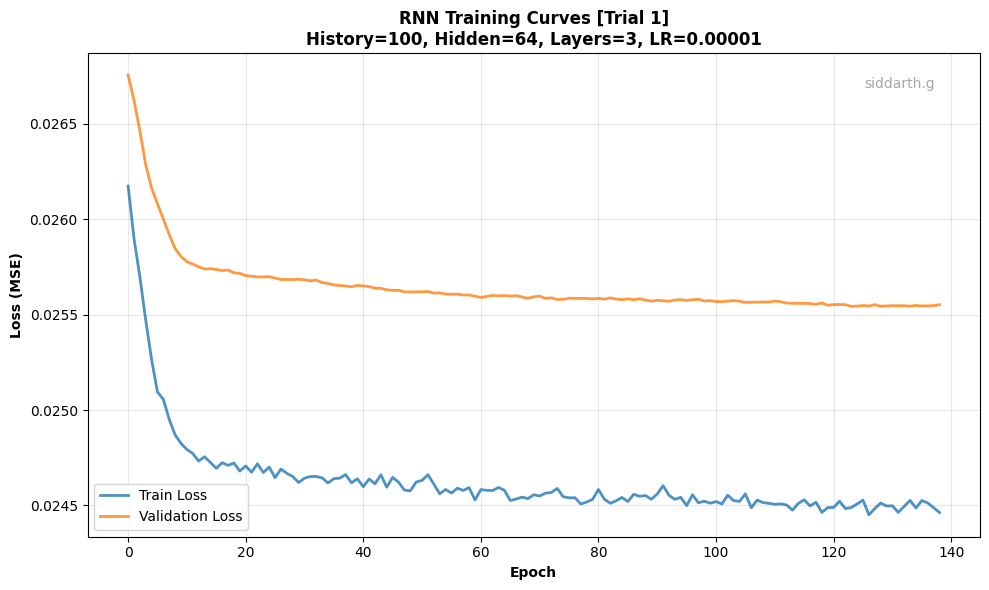


[Trial 2] Testing: history=5, hidden=64, layers=2, dropout=0.00, lr=0.00003, batch=64


  Results: Train=0.024644, Val=0.025775, Test=0.024279, Epochs=128
  Parameters: 12673


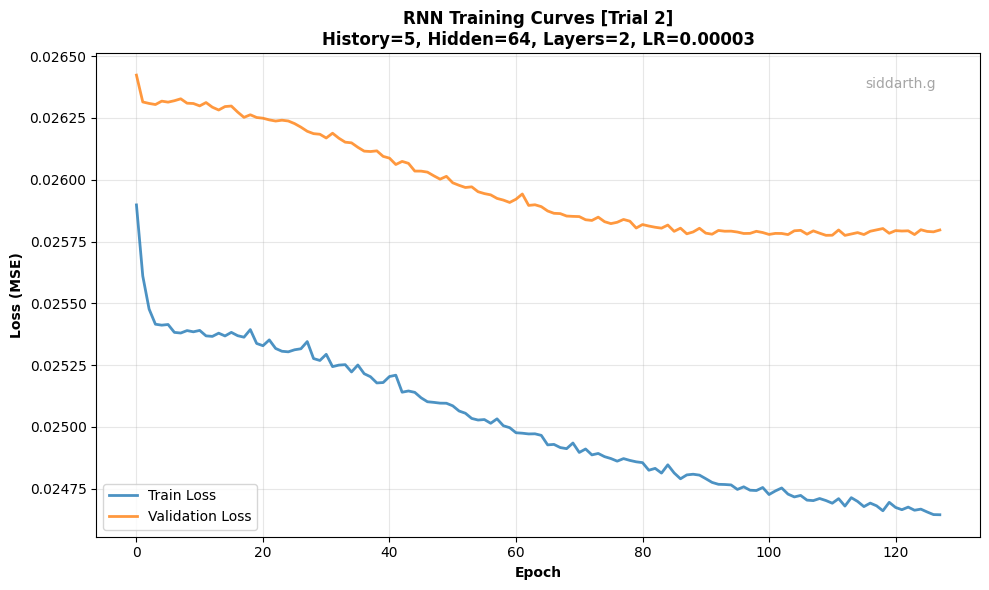


[Trial 3] Testing: history=5, hidden=128, layers=3, dropout=0.00, lr=0.00005, batch=64


  Results: Train=0.024686, Val=0.025738, Test=0.024264, Epochs=39
  Parameters: 82945


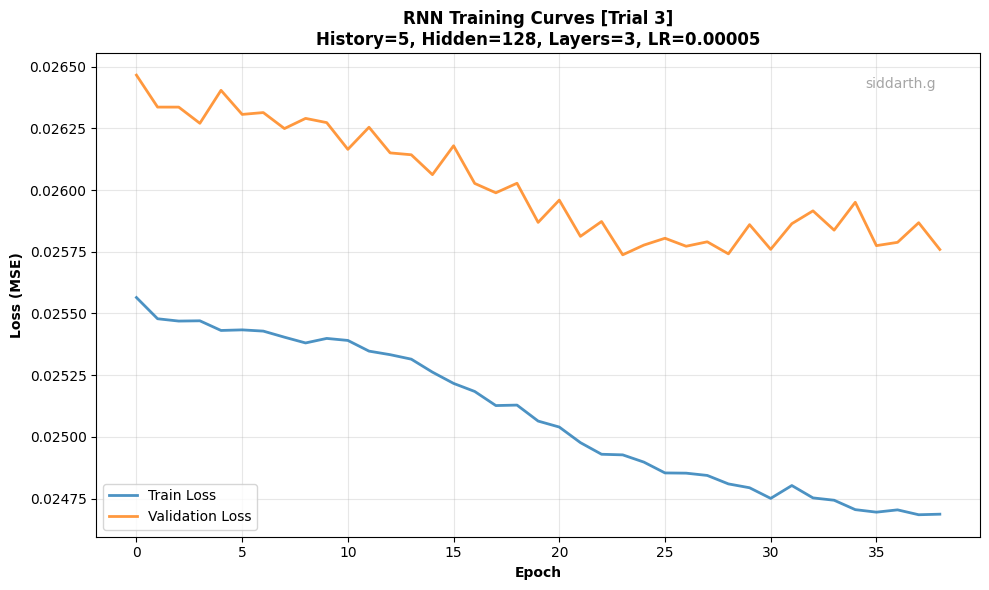


[Trial 4] Testing: history=50, hidden=128, layers=1, dropout=0.00, lr=0.00003, batch=64


  Results: Train=0.024041, Val=0.025232, Test=0.023379, Epochs=200
  Parameters: 16897
  >> New best model! Val loss: 0.025232


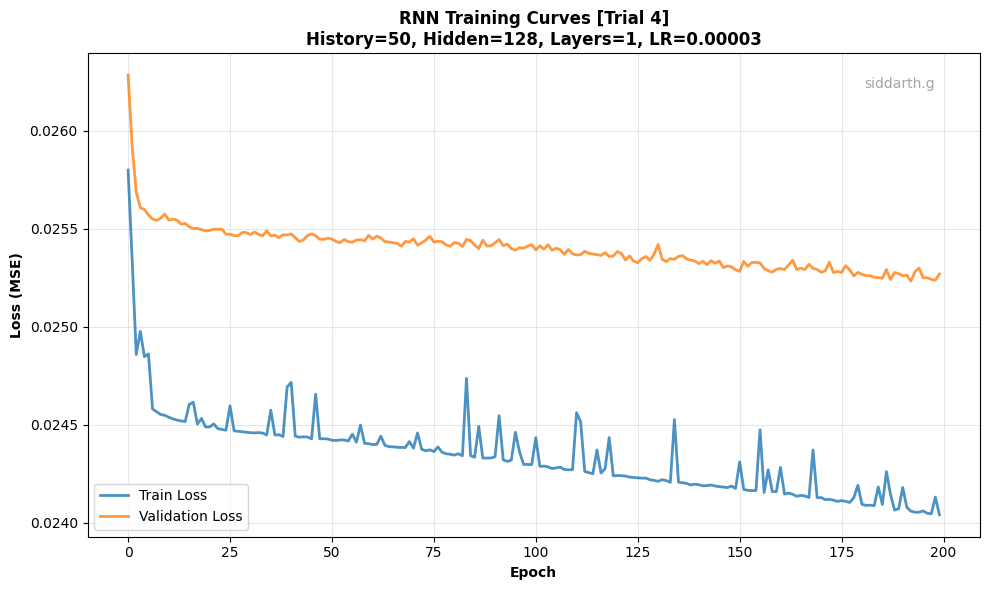


[Trial 5] Testing: history=25, hidden=64, layers=3, dropout=0.00, lr=0.00001, batch=64


  Results: Train=0.024326, Val=0.025297, Test=0.023776, Epochs=200
  Parameters: 20993


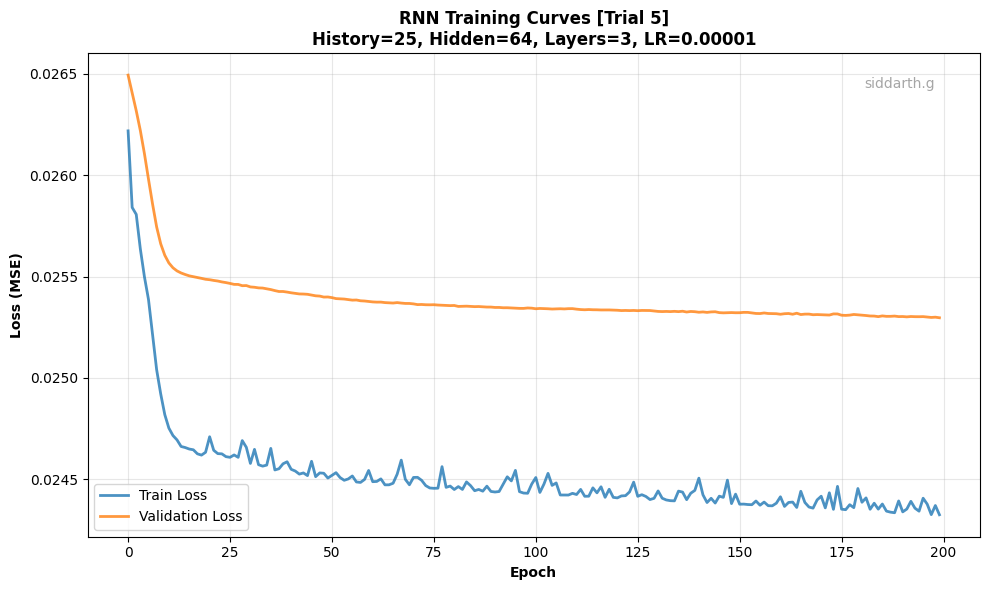


[Trial 6] Testing: history=50, hidden=64, layers=3, dropout=0.00, lr=0.00005, batch=64


  Results: Train=0.024342, Val=0.025427, Test=0.023549, Epochs=33
  Parameters: 20993


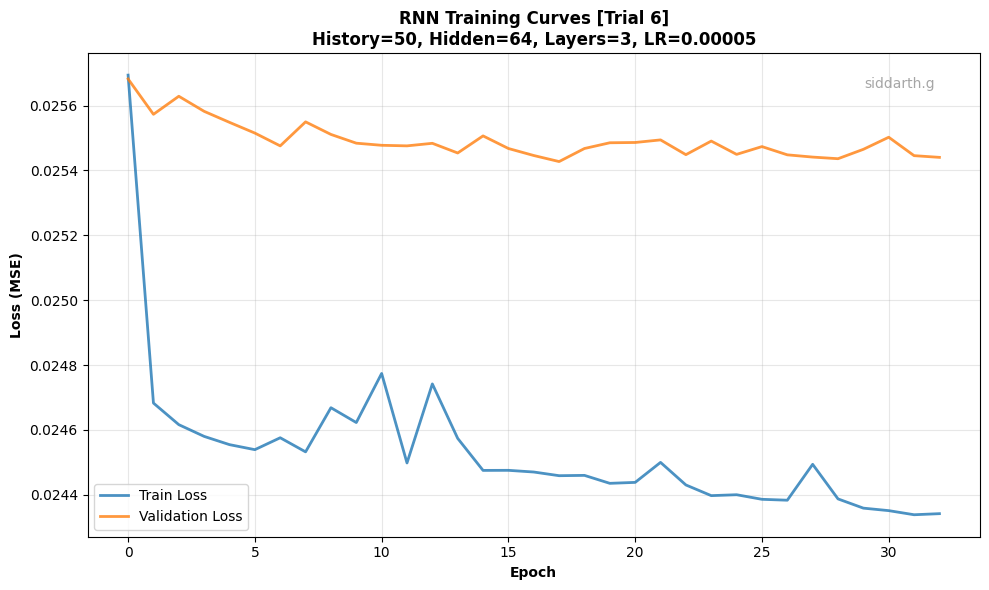


[Trial 7] Testing: history=50, hidden=64, layers=1, dropout=0.00, lr=0.00003, batch=64


  Results: Train=0.024141, Val=0.025290, Test=0.023388, Epochs=200
  Parameters: 4353


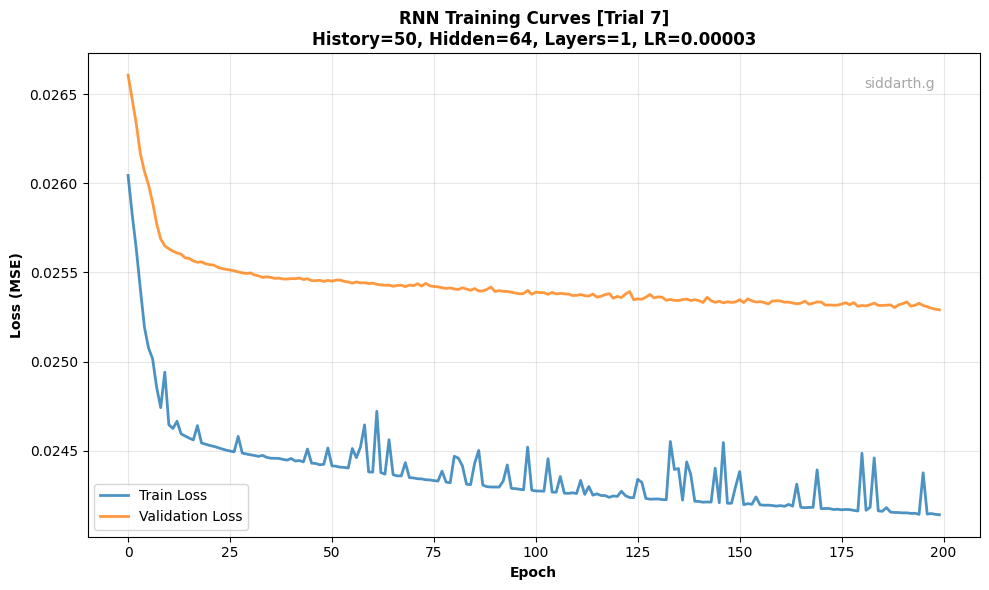


[Trial 8] Testing: history=25, hidden=64, layers=1, dropout=0.00, lr=0.00003, batch=64


  Results: Train=0.024171, Val=0.025207, Test=0.023664, Epochs=200
  Parameters: 4353
  >> New best model! Val loss: 0.025207


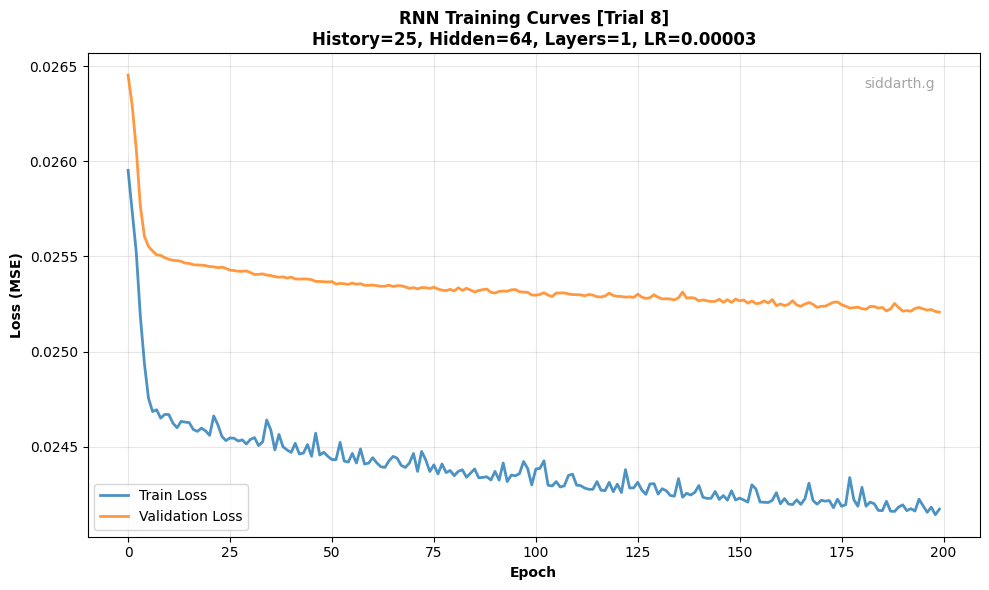


[Trial 9] Testing: history=50, hidden=128, layers=1, dropout=0.00, lr=0.00001, batch=64


  Results: Train=0.024749, Val=0.025462, Test=0.023557, Epochs=155
  Parameters: 16897


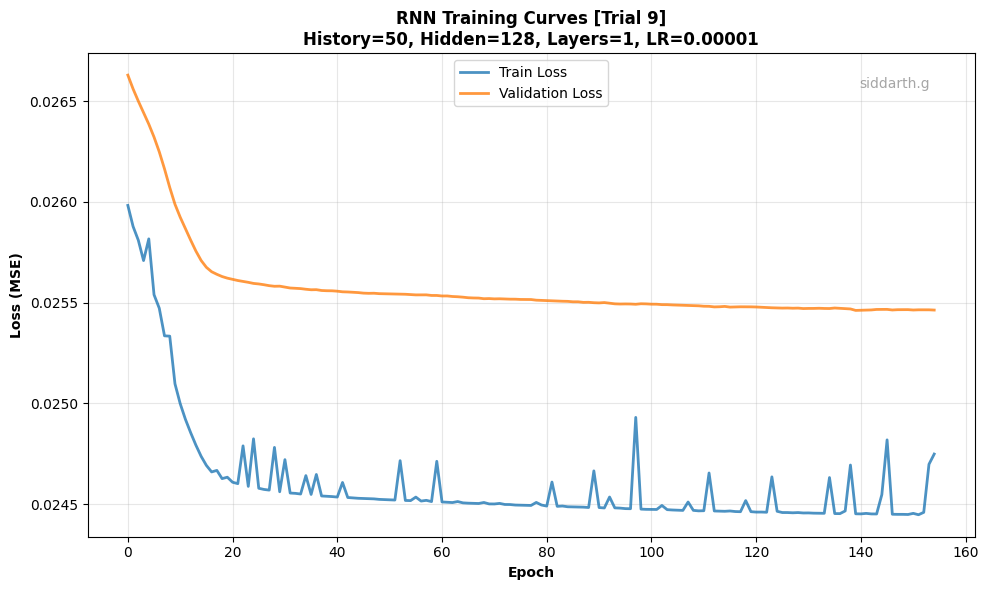


[Trial 10] Testing: history=100, hidden=64, layers=1, dropout=0.00, lr=0.00001, batch=64


  Results: Train=0.024533, Val=0.025647, Test=0.023541, Epochs=200
  Parameters: 4353


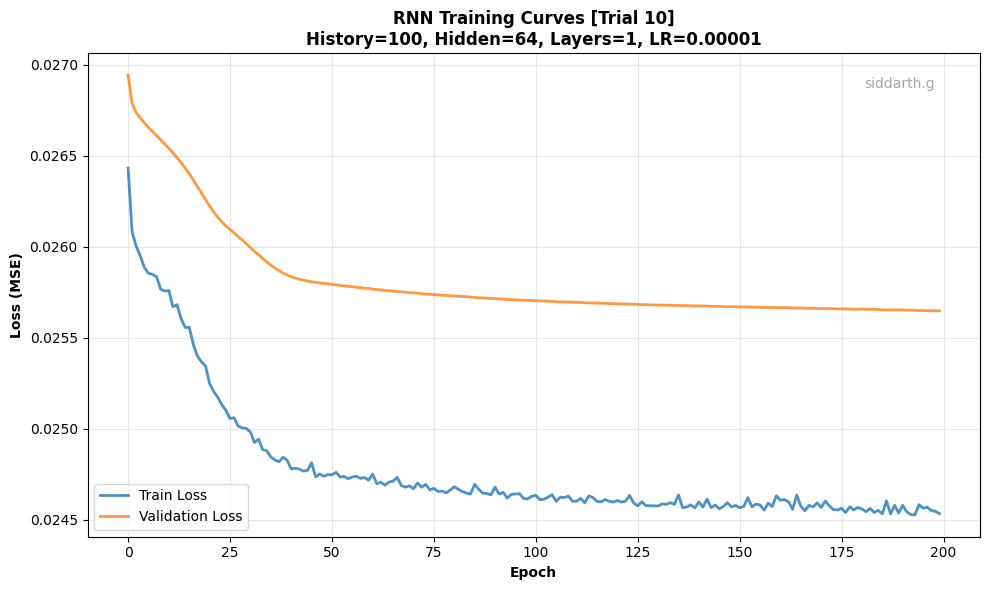


RNN BAYESIAN OPTIMIZATION COMPLETE

Best hyperparameters found:
  History length: 25
  Hidden size: 64
  Num layers: 1
  Dropout: 0.00
  Learning rate: 0.00003
  Batch size (fixed): 64
  Best validation loss: 0.025207

RNN RESULTS - TOP 10 CONFIGURATIONS
History    Hidden   Layers   Dropout    LR         Batch    Train Loss   Val Loss     Test Loss   
------------------------------------------------------------------------------------------------------------------------
25         64       1        0.00       0.00003    64       0.024171     0.025207     0.023664    
50         128      1        0.00       0.00003    64       0.024041     0.025232     0.023379    
50         64       1        0.00       0.00003    64       0.024141     0.025290     0.023388    
25         64       3        0.00       0.00001    64       0.024326     0.025297     0.023776    
50         64       3        0.00       0.00005    64       0.024342     0.025427     0.023549    
50         128      1        

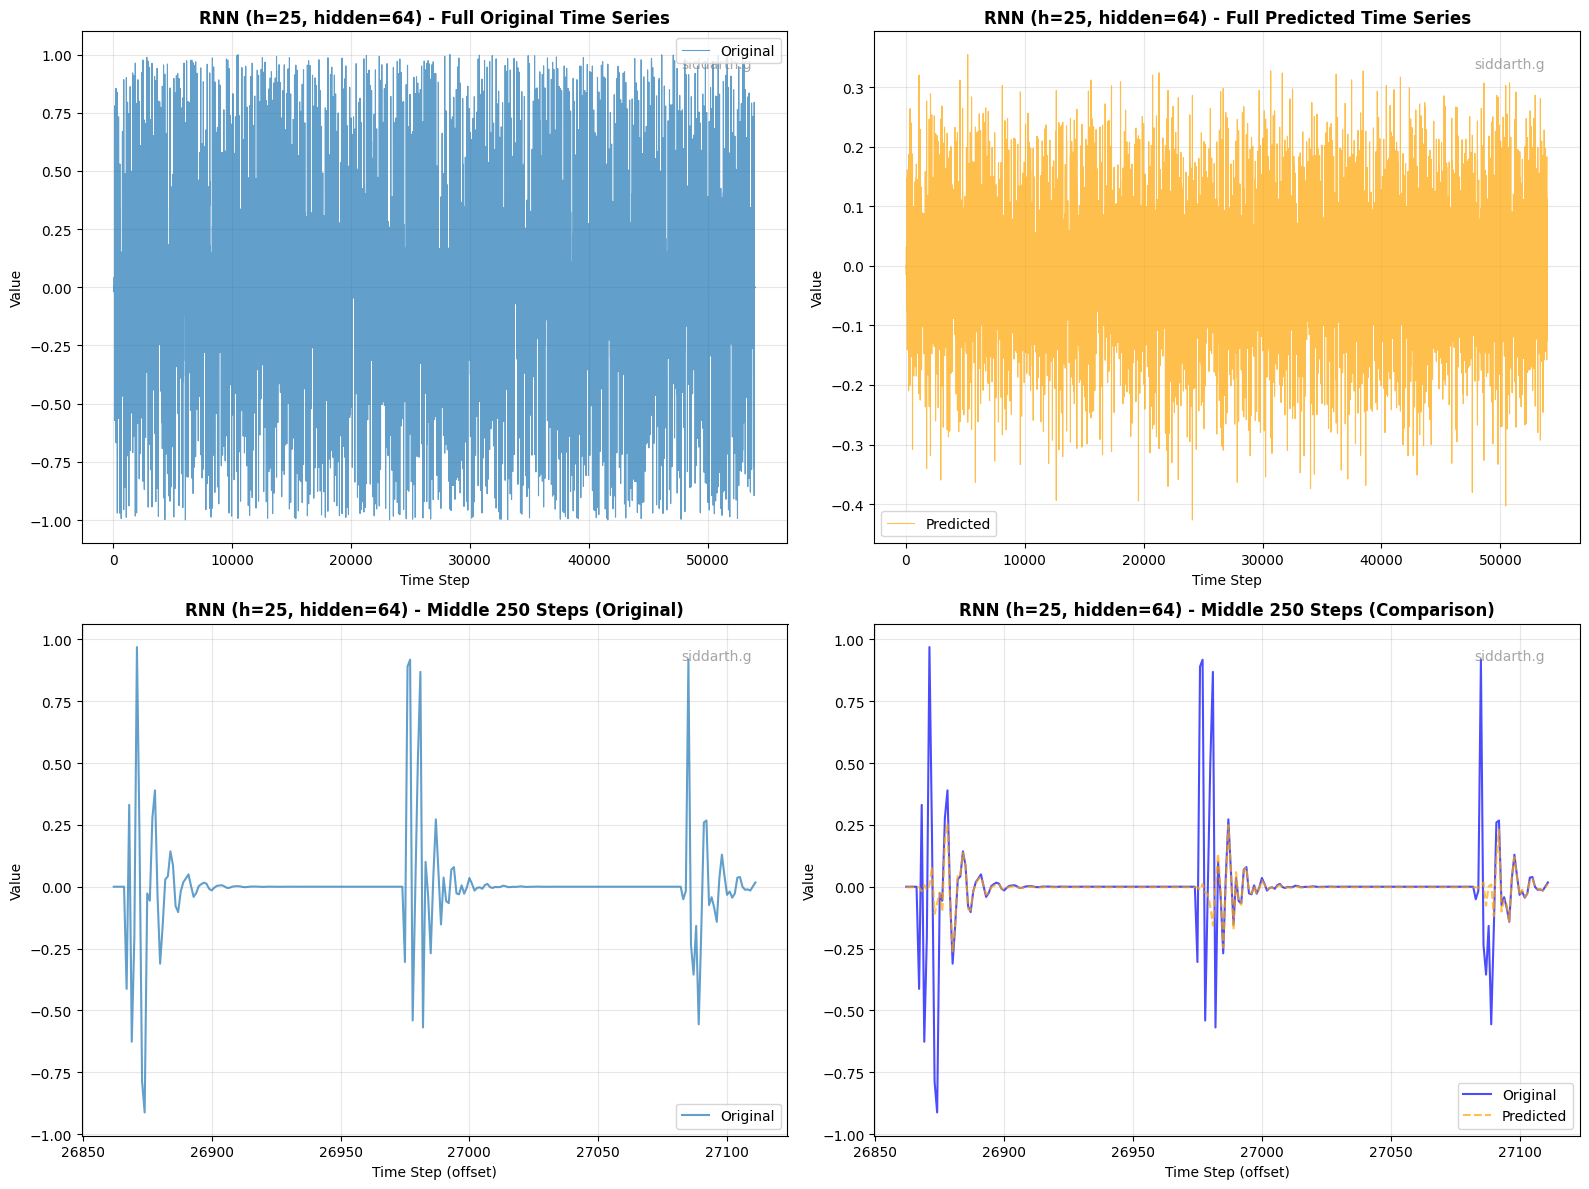


RNN (h=25, hidden=64) - Full Series Prediction Metrics:
  MSE: 0.024240
  MAE: 0.041013
  Predicted 53975 time steps (excluding initial 25 history)



In [94]:
class VanillaRNNModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(VanillaRNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            nonlinearity='tanh'
        )
        
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        x = x.unsqueeze(-1)
        rnn_out, _ = self.rnn(x)
        last_output = rnn_out[:, -1, :]
        prediction = self.fc(last_output)
        return prediction.squeeze()


class RNNPredictor:
    """Wrapper for RNN model to provide consistent interface with MLP"""
    def __init__(self, model):
        self.model = model
    
    def predict(self, X, scaler_y):
        self.model.eval()
        with torch.no_grad():
            X_t = torch.FloatTensor(X).to(device)
            scaled_predictions = self.model(X_t)
            # Inverse transform predictions to original scale
            unscaled_predictions = scaler_y.inverse_transform(scaled_predictions.cpu().numpy().reshape(-1, 1)).flatten()
            return unscaled_predictions


def train_rnn(model, X_train, y_train, X_val, y_val, X_test, y_test, scaler_y, epochs=200, batch_size=64, lr=0.001, patience=15, model_name='RNN', verbose=False):
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train)
    X_val_t = torch.FloatTensor(X_val).to(device)
    y_val_t = torch.FloatTensor(y_val).to(device)
    X_test_t = torch.FloatTensor(X_test).to(device)
    y_test_t = torch.FloatTensor(y_test).to(device)

    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True if device.type == 'cuda' else False)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    train_loss_history = []
    val_loss_history = []

    epoch_pbar = tqdm(range(epochs), desc="RNN Training", leave=False)
    for epoch in epoch_pbar:
        model.train()
        train_batch_losses = []

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            
            # Compute loss on scaled data for backpropagation
            loss = criterion(outputs.squeeze(), batch_y)
            
            loss.backward()
            optimizer.step()

            # Compute loss on original scale for reporting
            reporting_loss = inverse_transform_and_compute_loss(outputs, batch_y, scaler_y, criterion)
            train_batch_losses.append(reporting_loss.item())

        avg_train_loss = np.mean(train_batch_losses)
        train_loss_history.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            # Compute validation loss on original scale
            val_loss = inverse_transform_and_compute_loss(val_outputs, y_val_t, scaler_y, criterion).item()
        val_loss_history.append(val_loss)
        
        epoch_pbar.set_postfix({'train_loss': avg_train_loss, 'val_loss': val_loss})

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break
    
    epoch_pbar.close()
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_t)
        # Compute test loss on original scale
        test_loss = inverse_transform_and_compute_loss(test_outputs, y_test_t, scaler_y, criterion).item()
    
    final_train_loss = train_loss_history[-1] if train_loss_history else float('inf')

    return model, final_train_loss, best_val_loss, test_loss, train_loss_history, val_loss_history

print("="*60)
print("RNN MODEL - BAYESIAN HYPERPARAMETER OPTIMIZATION")
print("="*60)

rnn_results = []
rnn_trial_counter = 0

# Define discrete parameter lists
RNN_HISTORY_LENGTHS = [5, 25, 50, 100]
RNN_HIDDEN_SIZES = [64, 128]
RNN_NUM_LAYERS = [1, 2, 3]
RNN_DROPOUTS = [0.0, 0.1]
RNN_LEARNING_RATES = [0.000005, 0.00001, 0.000025, 0.00005]
RNN_BATCH_SIZE = 64  # Fixed

# Define search space - use Integer for indices
rnn_search_space = [
    Categorical(RNN_HISTORY_LENGTHS, name='history_length'),
    Categorical(RNN_HIDDEN_SIZES, name='hidden_size'),
    Categorical(RNN_NUM_LAYERS, name='num_layers'),
    Categorical(RNN_DROPOUTS, name='dropout'),
    Categorical(RNN_LEARNING_RATES, name='learning_rate')
]

@use_named_args(rnn_search_space)
def rnn_objective(history_length, hidden_size, num_layers, dropout, learning_rate):
    global rnn_trial_counter, best_overall_val_loss, best_overall_model_info, rnn_results
    
    rnn_trial_counter += 1
    batch_size = RNN_BATCH_SIZE
    
    # If num_layers is 1, set dropout to 0
    if num_layers == 1:
        dropout = 0.0
    
    config = {
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'dropout': dropout,
        'lr': learning_rate,
        'batch_size': batch_size
    }
    
    print(f"\n[Trial {rnn_trial_counter}] Testing: history={history_length}, hidden={hidden_size}, layers={num_layers}, dropout={dropout:.2f}, lr={learning_rate:.5f}, batch={batch_size}")
    
    try:
        data_dict = data_configs[history_length]
        X_train_scaled = data_dict['X_train_scaled']
        y_train_scaled = data_dict['y_train_scaled']
        X_val_scaled = data_dict['X_val_scaled']
        y_val_scaled = data_dict['y_val_scaled']
        X_test_scaled = data_dict['X_test_scaled']
        y_test_scaled = data_dict['y_test_scaled']
        scaler_y = data_dict['scaler_y']
        
        model = VanillaRNNModel(
            input_size=history_length,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout
        ).to(device)

        trained_model, train_loss, val_loss, test_loss, train_history, val_history = train_rnn(
            model, X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled, X_test_scaled, y_test_scaled, scaler_y,
            epochs=200, batch_size=batch_size, lr=learning_rate, model_name='RNN', verbose=False
        )
        
        num_params = count_parameters(trained_model, 'rnn')
        
        print(f"  Results: Train={train_loss:.6f}, Val={val_loss:.6f}, Test={test_loss:.6f}, Epochs={len(train_history)}")
        print(f"  Parameters: {num_params}")
        
        # Log to CSV
        with open(csv_file, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['RNN', history_length, train_loss, val_loss, test_loss, num_params])

        # Track best model
        if val_loss < best_overall_val_loss:
            best_overall_val_loss = val_loss
            
            if 'path' in best_overall_model_info and os.path.exists(best_overall_model_info['path']):
                os.remove(best_overall_model_info['path'])
            
            model_path = f"saved_models/best_rnn_h{history_length}_hidden{hidden_size}_layers{num_layers}_lr{learning_rate:.5f}.pt"
            torch.save(trained_model.state_dict(), model_path)
            
            best_overall_model_info = {
                'type': 'RNN',
                'path': model_path,
                'history_length': history_length,
                'config': config,
                'val_loss': val_loss
            }
            print(f"  >> New best model! Val loss: {val_loss:.6f}")
        
        # Plot training curves for this trial
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(train_history, label='Train Loss', linewidth=2, alpha=0.8)
        ax.plot(val_history, label='Validation Loss', linewidth=2, alpha=0.8)
        ax.set_xlabel('Epoch', fontweight='bold')
        ax.set_ylabel('Loss (MSE)', fontweight='bold')
        ax.set_title(f'RNN Training Curves [Trial {rnn_trial_counter}]\nHistory={history_length}, Hidden={hidden_size}, Layers={num_layers}, LR={learning_rate:.5f}', 
                     fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        add_username(ax)
        plt.tight_layout()
        plt.show()

        rnn_results.append({
            'model': trained_model,
            'history_length': history_length,
            'config': config,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'test_loss': test_loss
        })
        
        return val_loss
    
    except Exception as e:
        print(f"  Error in trial: {e}")
        return float('inf')

# Calculate total number of combinations (accounting for dropout=0 when layers=1)
total_combinations = len(RNN_HISTORY_LENGTHS) * len(RNN_HIDDEN_SIZES) * len(RNN_LEARNING_RATES) * (
    len(RNN_DROPOUTS) * (len(RNN_NUM_LAYERS) - 1) + 1  # 1 layer with dropout=0, other layers with all dropouts
)
n_calls = min(10, total_combinations)

print(f"\nParameter space:")
print(f"  History lengths: {RNN_HISTORY_LENGTHS}")
print(f"  Hidden sizes: {RNN_HIDDEN_SIZES}")
print(f"  Num layers: {RNN_NUM_LAYERS}")
print(f"  Dropouts: {RNN_DROPOUTS} (0 if num_layers=1)")
print(f"  Learning rates: {RNN_LEARNING_RATES}")
print(f"  Batch size (fixed): {RNN_BATCH_SIZE}")
print(f"  Total combinations (approx): {total_combinations}")
print(f"  Trials to run: {n_calls}")

# Run Bayesian optimization
print(f"\nStarting Bayesian optimization for RNN ({n_calls} iterations)...")
result = gp_minimize(
    rnn_objective,
    rnn_search_space,
    n_calls=n_calls,
    n_initial_points=min(10, n_calls),
    random_state=42,
    verbose=False
)

print("\n" + "="*60)
print("RNN BAYESIAN OPTIMIZATION COMPLETE")
print("="*60)
print(f"\nBest hyperparameters found:")
print(f"  History length: {result.x[0]}")
print(f"  Hidden size: {result.x[1]}")
print(f"  Num layers: {result.x[2]}")
print(f"  Dropout: {result.x[3]:.2f}")
print(f"  Learning rate: {result.x[4]:.5f}")
print(f"  Batch size (fixed): {RNN_BATCH_SIZE}")
print(f"  Best validation loss: {result.fun:.6f}")

print("\n" + "="*60)
print("RNN RESULTS - TOP 10 CONFIGURATIONS")
print("="*60)
print(f"{'History':<10} {'Hidden':<8} {'Layers':<8} {'Dropout':<10} {'LR':<10} {'Batch':<8} {'Train Loss':<12} {'Val Loss':<12} {'Test Loss':<12}")
print("-"*120)
for res in sorted(rnn_results, key=lambda x: x['val_loss'])[:10]:
    cfg = res['config']
    print(f"{res['history_length']:<10} {cfg['hidden_size']:<8} {cfg['num_layers']:<8} {cfg['dropout']:<10.2f} {cfg['lr']:<10.5f} {cfg['batch_size']:<8} {res['train_loss']:<12.6f} {res['val_loss']:<12.6f} {res['test_loss']:<12.6f}")
print("="*120)

best_rnn = min(rnn_results, key=lambda x: x['val_loss'])
vanilla_rnn_model = best_rnn['model']
best_rnn_history = best_rnn['history_length']

print(f"\nBest RNN configuration:")
print(f"  History length: {best_rnn_history}")
print(f"  Hidden size: {best_rnn['config']['hidden_size']}")
print(f"  Num layers: {best_rnn['config']['num_layers']}")
print(f"  Dropout: {best_rnn['config']['dropout']:.2f}")
print(f"  Learning rate: {best_rnn['config']['lr']:.5f}")
print(f"  Batch size: {best_rnn['config']['batch_size']}")
print(f"  Validation loss: {best_rnn['val_loss']:.6f}")

# Plot time series predictions for best RNN model
print("\n" + "="*60)
print("RNN - TIME SERIES PREDICTION VISUALIZATION")
print("="*60)
data_dict_best_rnn = data_configs[best_rnn_history]
rnn_predictor = RNNPredictor(vanilla_rnn_model)
plot_time_series_predictions(
    rnn_predictor, 
    'rnn', 
    data_dict_best_rnn, 
    data, 
    best_rnn_history,
    f'RNN (h={best_rnn_history}, hidden={best_rnn["config"]["hidden_size"]})'
)

print("\n" + "="*60)


BEST MODELS FROM EACH CATEGORY
        Model  History_Length  Train_Loss  Val_Loss  Test_Loss  Num_Parameters
2   Linear_AR              25    0.024456  0.025332   0.023775              26
10        MLP              50    0.024065  0.025261   0.023398           14849
22        RNN              25    0.024171  0.025207   0.023664            4353

ANALYTICAL RECURRENCE RELATIONS

1. Linear AR (History Length: 25):
   x_k = 0.031741 * x_(k-1) + -0.041869 * x_(k-2) + -0.040788 * x_(k-3) + -0.062019 * x_(k-4) + -0.077155 * x_(k-5) + 0.087554 * x_(k-6) + 0.152380 * x_(k-7) + -0.074938 * x_(k-8) + -0.021673 * x_(k-9) + -0.006101 * x_(k-10) + -0.007005 * x_(k-11) + 0.001599 * x_(k-12) + 0.011665 * x_(k-13) + 0.002194 * x_(k-14) + -0.003292 * x_(k-15) + -0.001591 * x_(k-16) + -0.000801 * x_(k-17) + -0.000278 * x_(k-18) + 0.000728 * x_(k-19) + 0.000646 * x_(k-20) + -0.000074 * x_(k-21) + -0.000265 * x_(k-22) + -0.000158 * x_(k-23) + -0.000082 * x_(k-24) + 0.000014 * x_(k-25) + -0.000711

2. MLP

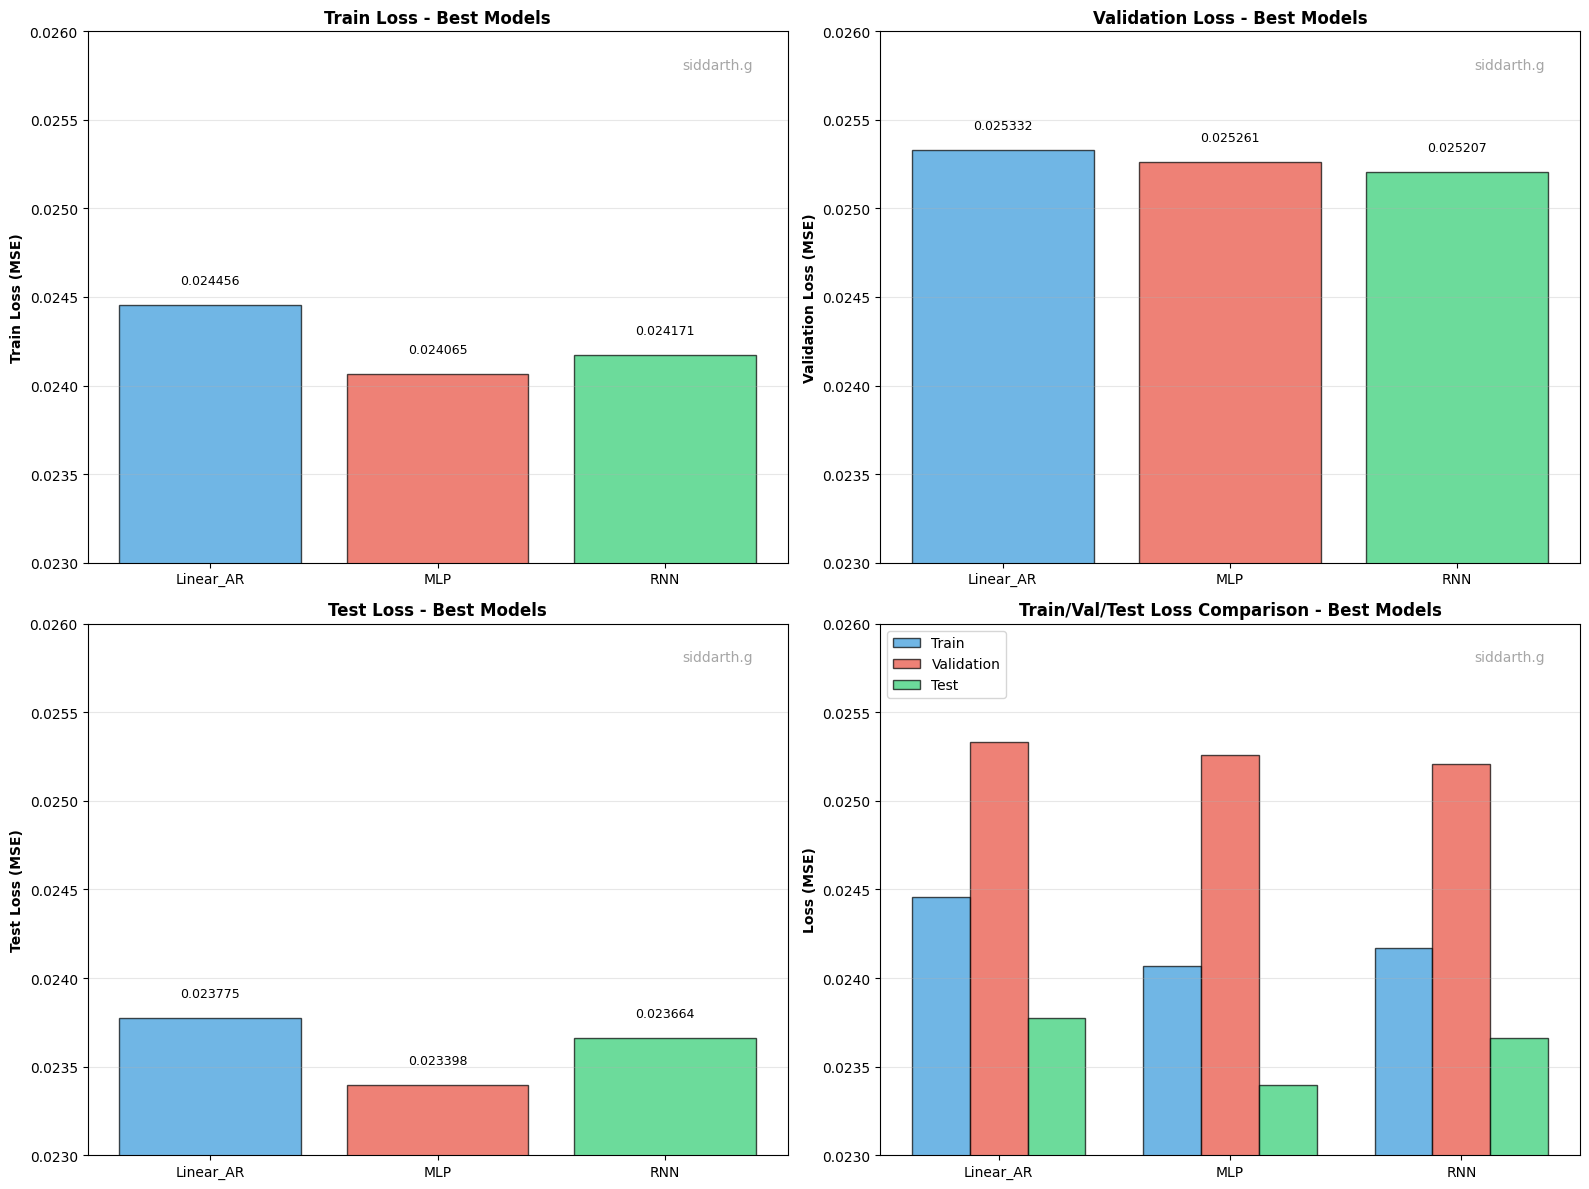


PARAMETER COUNT VS LOSS ANALYSIS


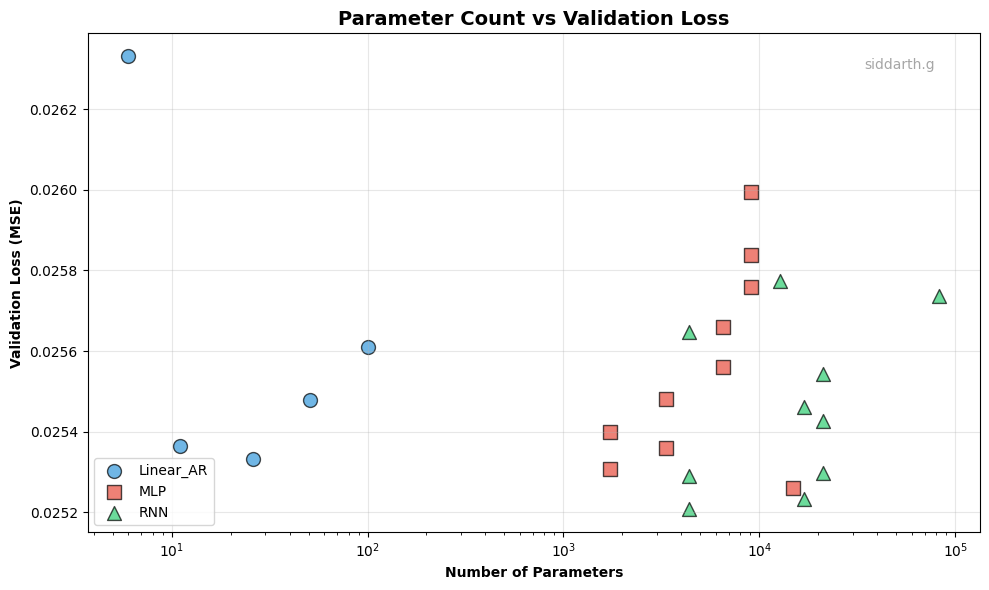

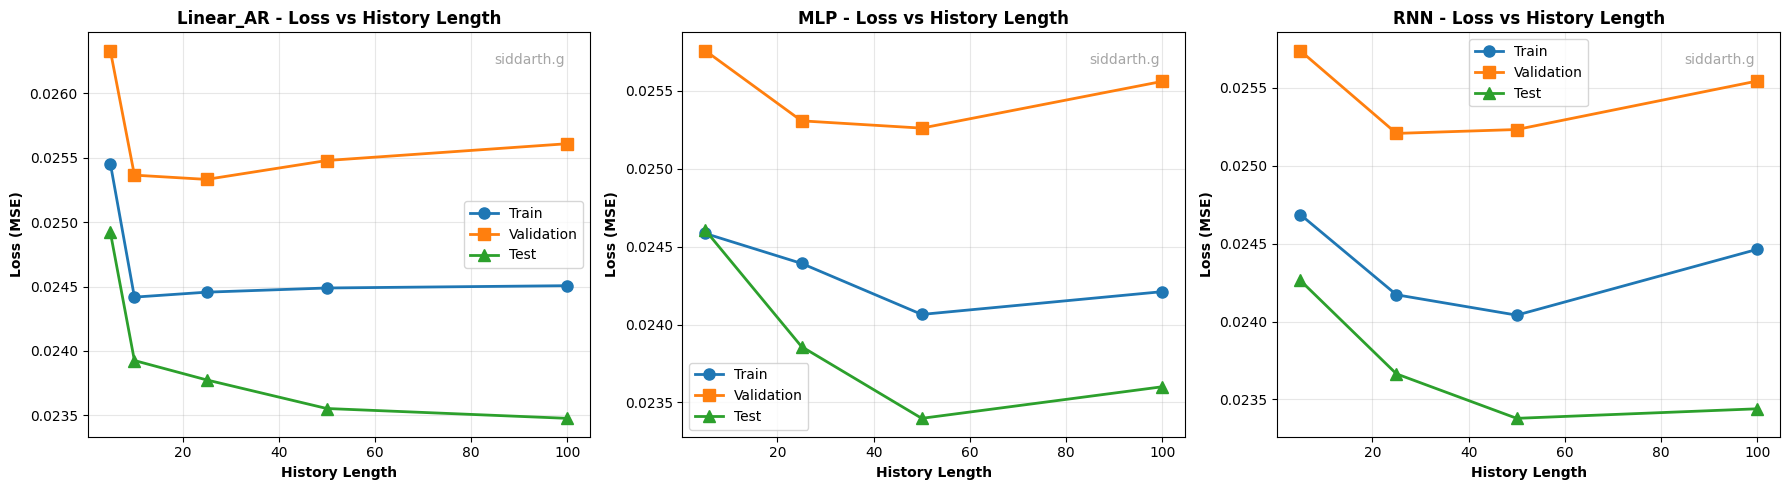

In [95]:
# Load the CSV file
results_df = pd.read_csv(csv_file)

# Get best model from each category based on validation loss
best_models = results_df.loc[results_df.groupby('Model')['Val_Loss'].idxmin()]

print("\n" + "="*60)
print("BEST MODELS FROM EACH CATEGORY")
print("="*60)
print(best_models[['Model', 'History_Length', 'Train_Loss', 'Val_Loss', 'Test_Loss', 'Num_Parameters']])

# Print analytical recurrence relations
print("\n" + "="*60)
print("ANALYTICAL RECURRENCE RELATIONS")
print("="*60)

# Linear AR recurrence
print(f"\n1. Linear AR (History Length: {best_linear_ar_history}):")
expression_terms = [f"{coef:.6f} * x_(k-{i})" for i, coef in enumerate(linear_ar_model.ar_coefs, 1)]
expression = " + ".join(expression_terms)
expression = f"x_k = {expression} + {linear_ar_model.intercept:.6f}"
print(f"   {expression}")

# MLP recurrence (structure description)
print(f"\n2. MLP (History Length: {best_mlp_history}, Architecture: {best_mlp['architecture']}):")
print(f"   x_k = MLP([x_(k-{best_mlp_history}), ..., x_(k-1)])")
print(f"   Non-linear feedforward network with {len(best_mlp['architecture'])} hidden layers")
print(f"   Layer sizes: {best_mlp_history} -> {' -> '.join(map(str, best_mlp['architecture']))} -> 1")

# RNN recurrence (structure description)
print(f"\n3. RNN (History Length: {best_rnn_history}, Hidden Size: {best_rnn['config']['hidden_size']}, Layers: {best_rnn['config']['num_layers']}):")
print(f"   h_t = tanh(W_hh * h_(t-1) + W_xh * x_t + b_h)")
print(f"   x_k = W_out * h_k + b_out")
print(f"   Recurrent network processing sequence [x_(k-{best_rnn_history}), ..., x_(k-1)]")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Train Loss Comparison
ax = axes[0, 0]
x_pos = np.arange(len(best_models))
colors = ['#3498db', '#e74c3c', '#2ecc71']
ax.bar(x_pos, best_models['Train_Loss'], color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(best_models['Model'])
ax.set_ylabel('Train Loss (MSE)', fontweight='bold')
ax.set_title('Train Loss - Best Models', fontsize=12, fontweight='bold')
ax.set_ylim(0.023, 0.026)
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(best_models['Train_Loss']):
    ax.text(i, v + 0.0001, f'{v:.6f}', ha='center', va='bottom', fontsize=9)
add_username(ax)

# Validation Loss Comparison
ax = axes[0, 1]
ax.bar(x_pos, best_models['Val_Loss'], color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(best_models['Model'])
ax.set_ylabel('Validation Loss (MSE)', fontweight='bold')
ax.set_title('Validation Loss - Best Models', fontsize=12, fontweight='bold')
ax.set_ylim(0.023, 0.026)
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(best_models['Val_Loss']):
    ax.text(i, v + 0.0001, f'{v:.6f}', ha='center', va='bottom', fontsize=9)
add_username(ax)

# Test Loss Comparison
ax = axes[1, 0]
ax.bar(x_pos, best_models['Test_Loss'], color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(best_models['Model'])
ax.set_ylabel('Test Loss (MSE)', fontweight='bold')
ax.set_title('Test Loss - Best Models', fontsize=12, fontweight='bold')
ax.set_ylim(0.023, 0.026)
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(best_models['Test_Loss']):
    ax.text(i, v + 0.0001, f'{v:.6f}', ha='center', va='bottom', fontsize=9)
add_username(ax)

# All Losses Side-by-Side
ax = axes[1, 1]
width = 0.25
x_pos = np.arange(len(best_models))
ax.bar(x_pos - width, best_models['Train_Loss'], width, label='Train', color='#3498db', alpha=0.7, edgecolor='black')
ax.bar(x_pos, best_models['Val_Loss'], width, label='Validation', color='#e74c3c', alpha=0.7, edgecolor='black')
ax.bar(x_pos + width, best_models['Test_Loss'], width, label='Test', color='#2ecc71', alpha=0.7, edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(best_models['Model'])
ax.set_ylabel('Loss (MSE)', fontweight='bold')
ax.set_title('Train/Val/Test Loss Comparison - Best Models', fontsize=12, fontweight='bold')
ax.set_ylim(0.023, 0.026)
ax.legend()
ax.grid(axis='y', alpha=0.3)
add_username(ax)

plt.tight_layout()
plt.show()

# Parameter Count vs Loss Analysis
print("\n" + "="*60)
print("PARAMETER COUNT VS LOSS ANALYSIS")
print("="*60)

fig, ax = plt.subplots(figsize=(10, 6))
for model_name, color, marker in zip(['Linear_AR', 'MLP', 'RNN'], colors, ['o', 's', '^']):
    model_data = results_df[results_df['Model'] == model_name]
    ax.scatter(model_data['Num_Parameters'], model_data['Val_Loss'], 
               label=model_name, color=color, s=100, alpha=0.7, edgecolor='black', marker=marker)

ax.set_xlabel('Number of Parameters', fontweight='bold')
ax.set_ylabel('Validation Loss (MSE)', fontweight='bold')
ax.set_title('Parameter Count vs Validation Loss', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
add_username(ax)
plt.tight_layout()
plt.show()

# History length analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, model_name in enumerate(['Linear_AR', 'MLP', 'RNN']):
    ax = axes[idx]
    model_data = results_df[results_df['Model'] == model_name]
    
    if len(model_data) > 0:
        # Group by history length and get best (min val loss) for each
        best_per_history = model_data.loc[model_data.groupby('History_Length')['Val_Loss'].idxmin()]
        
        ax.plot(best_per_history['History_Length'], best_per_history['Train_Loss'], 
                marker='o', label='Train', linewidth=2, markersize=8)
        ax.plot(best_per_history['History_Length'], best_per_history['Val_Loss'], 
                marker='s', label='Validation', linewidth=2, markersize=8)
        ax.plot(best_per_history['History_Length'], best_per_history['Test_Loss'], 
                marker='^', label='Test', linewidth=2, markersize=8)
        
        ax.set_xlabel('History Length', fontweight='bold')
        ax.set_ylabel('Loss (MSE)', fontweight='bold')
        ax.set_title(f'{model_name} - Loss vs History Length', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        add_username(ax)

plt.tight_layout()
plt.show()


## Autoregressive Forecasting Analysis

Evaluate the prediction error growth as forecasting horizon increases by generating outputs autoregressively.

AUTOREGRESSIVE FORECASTING ANALYSIS

Linear AR Forecasting:
  MSE: 0.025381, MAE: 0.048994

MLP Forecasting:
  MSE: 0.025241, MAE: 0.046962

RNN Forecasting:
  MSE: 0.025376, MAE: 0.049599

AUTOREGRESSIVE FORECASTING VISUALIZATION


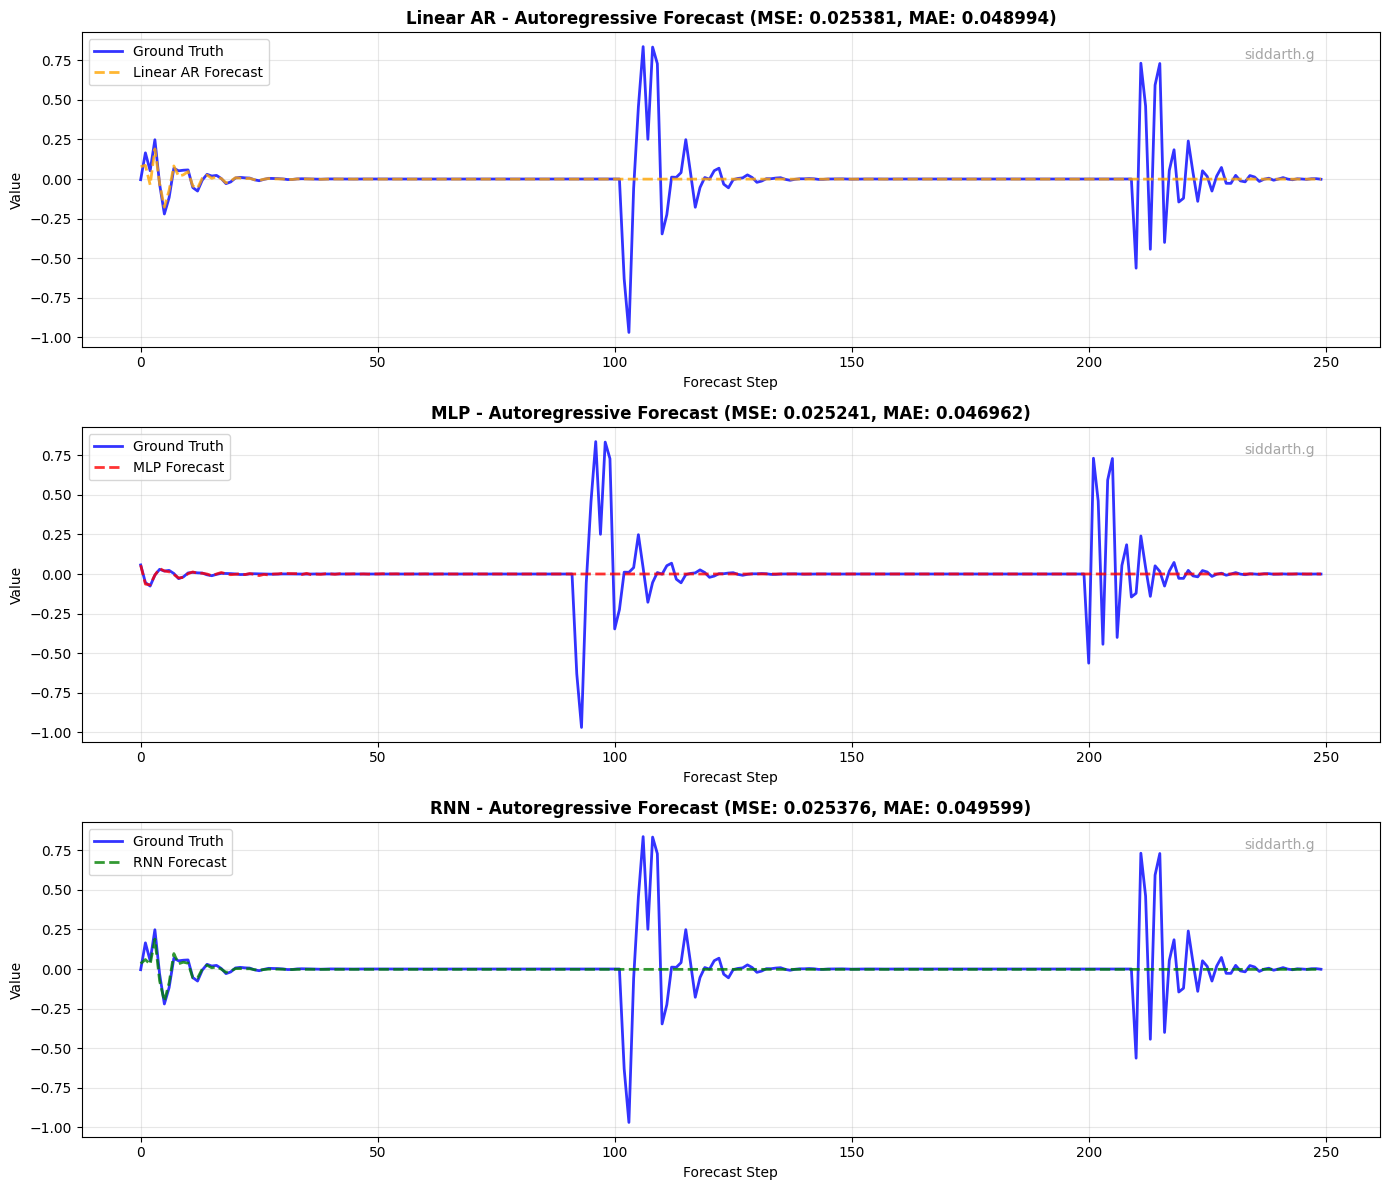


FORECASTING RESULTS SUMMARY
       Model  Forecast_Length  Input_Length  Start_Index       MSE       MAE
0  Linear_AR              250            25          197  0.025381  0.048994
1        MLP              250            50          197  0.025241  0.046962
2        RNN              250            25          197  0.025376  0.049599


In [121]:
def autoregressive_forecast_linear_ar(model, initial_input, n_steps, history_length):
    """Generate autoregressive forecasts using Linear AR model."""
    predictions = []
    current_input = initial_input.copy()

    for _ in range(n_steps):
        pred = model.predict(current_input.reshape(1, -1))[0]
        predictions.append(pred)
        current_input = np.roll(current_input, -1)
        current_input[-1] = pred

    return np.array(predictions)

def autoregressive_forecast_mlp(model, initial_input, n_steps, history_length, scaler_X, scaler_y):
    """Generate autoregressive forecasts using MLP model."""
    predictions = []
    current_input = initial_input.copy()

    for _ in range(n_steps):
        scaled_input = scaler_X.transform(current_input.reshape(1, -1))
        pred_scaled = model.model(torch.FloatTensor(scaled_input).to(device)).item()
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        predictions.append(pred)
        current_input = np.roll(current_input, -1)
        current_input[-1] = pred

    return np.array(predictions)

def autoregressive_forecast_rnn(model, initial_input, n_steps, history_length, scaler_X, scaler_y):
    """Generate autoregressive forecasts using RNN model."""
    predictions = []
    current_input = initial_input.copy()

    for _ in range(n_steps):
        scaled_input = scaler_X.transform(current_input.reshape(1, -1))
        scaled_input_tensor = torch.FloatTensor(scaled_input).to(device)
        pred_scaled = model(scaled_input_tensor).item()
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        predictions.append(pred)
        current_input = np.roll(current_input, -1)
        current_input[-1] = pred

    return np.array(predictions)

print("="*60)
print("AUTOREGRESSIVE FORECASTING ANALYSIS")
print("="*60)

# Choose a starting point from the test set
test_start_idx = 197
forecast_length = 250

# CSV file for forecasting results
forecast_csv = 'autoregressive_forecasting_results.csv'
with open(forecast_csv, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Model', 'Forecast_Length', 'Input_Length', 'Start_Index', 'MSE', 'MAE'])

# Store forecasts for each model
forecasts = {}

# Linear AR forecasting
print(f"\nLinear AR Forecasting:")
data_dict_linear = data_configs[best_linear_ar_history]
initial_input_linear = data[test_start_idx:test_start_idx + best_linear_ar_history]
ground_truth = data[test_start_idx + best_linear_ar_history:test_start_idx + best_linear_ar_history + forecast_length]

forecast_linear = autoregressive_forecast_linear_ar(
    linear_ar_model, initial_input_linear, forecast_length, best_linear_ar_history
)

mse_linear = mean_squared_error(ground_truth, forecast_linear)
mae_linear = mean_absolute_error(ground_truth, forecast_linear)
print(f"  MSE: {mse_linear:.6f}, MAE: {mae_linear:.6f}")

with open(forecast_csv, 'a', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Linear_AR', forecast_length, best_linear_ar_history, test_start_idx, mse_linear, mae_linear])

forecasts['Linear_AR'] = forecast_linear

# MLP forecasting
tmp = 15
print(f"\nMLP Forecasting:")
data_dict_mlp = data_configs[best_mlp_history]
initial_input_mlp = data[test_start_idx-tmp:test_start_idx-tmp + best_mlp_history]
ground_truth_mlp = data[test_start_idx-tmp + best_mlp_history:test_start_idx-tmp + best_mlp_history + forecast_length]

mlp_model.model.eval()
forecast_mlp = autoregressive_forecast_mlp(
    mlp_model, initial_input_mlp, forecast_length, best_mlp_history,
    data_dict_mlp['scaler_X'], data_dict_mlp['scaler_y']
)

mse_mlp = mean_squared_error(ground_truth_mlp, forecast_mlp)
mae_mlp = mean_absolute_error(ground_truth_mlp, forecast_mlp)
print(f"  MSE: {mse_mlp:.6f}, MAE: {mae_mlp:.6f}")

with open(forecast_csv, 'a', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['MLP', forecast_length, best_mlp_history, test_start_idx, mse_mlp, mae_mlp])

forecasts['MLP'] = forecast_mlp

# RNN forecasting
print(f"\nRNN Forecasting:")
data_dict_rnn = data_configs[best_rnn_history]
initial_input_rnn = data[test_start_idx:test_start_idx + best_rnn_history]
ground_truth_rnn = data[test_start_idx + best_rnn_history:test_start_idx + best_rnn_history + forecast_length]

vanilla_rnn_model.eval()
forecast_rnn = autoregressive_forecast_rnn(
    vanilla_rnn_model, initial_input_rnn, forecast_length, best_rnn_history,
    data_dict_rnn['scaler_X'], data_dict_rnn['scaler_y']
)

mse_rnn = mean_squared_error(ground_truth_rnn, forecast_rnn)
mae_rnn = mean_absolute_error(ground_truth_rnn, forecast_rnn)
print(f"  MSE: {mse_rnn:.6f}, MAE: {mae_rnn:.6f}")

with open(forecast_csv, 'a', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['RNN', forecast_length, best_rnn_history, test_start_idx, mse_rnn, mae_rnn])

forecasts['RNN'] = forecast_rnn

# Create 3x1 plot comparing all models
print("\n" + "="*60)
print("AUTOREGRESSIVE FORECASTING VISUALIZATION")
print("="*60)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Linear AR plot
ax = axes[0]
gt_linear = data[test_start_idx + best_linear_ar_history:test_start_idx + best_linear_ar_history + forecast_length]
ax.plot(range(forecast_length), gt_linear, label='Ground Truth', linewidth=2, alpha=0.8, color='blue')
ax.plot(range(forecast_length), forecast_linear, label='Linear AR Forecast', linewidth=2, alpha=0.8, color='orange', linestyle='--')
ax.set_title(f'Linear AR - Autoregressive Forecast (MSE: {mse_linear:.6f}, MAE: {mae_linear:.6f})', fontsize=12, fontweight='bold')
ax.set_xlabel('Forecast Step')
ax.set_ylabel('Value')
ax.legend()
ax.grid(True, alpha=0.3)
add_username(ax)

# MLP plot
ax = axes[1]
gt_mlp = data[test_start_idx-tmp + best_mlp_history:test_start_idx-tmp + best_mlp_history + forecast_length]
ax.plot(range(forecast_length), gt_mlp, label='Ground Truth', linewidth=2, alpha=0.8, color='blue')
ax.plot(range(forecast_length), forecast_mlp, label='MLP Forecast', linewidth=2, alpha=0.8, color='red', linestyle='--')
ax.set_title(f'MLP - Autoregressive Forecast (MSE: {mse_mlp:.6f}, MAE: {mae_mlp:.6f})', fontsize=12, fontweight='bold')
ax.set_xlabel('Forecast Step')
ax.set_ylabel('Value')
ax.legend()
ax.grid(True, alpha=0.3)
add_username(ax)

# RNN plot
ax = axes[2]
gt_rnn = data[test_start_idx + best_rnn_history:test_start_idx + best_rnn_history + forecast_length]
ax.plot(range(forecast_length), gt_rnn, label='Ground Truth', linewidth=2, alpha=0.8, color='blue')
ax.plot(range(forecast_length), forecast_rnn, label='RNN Forecast', linewidth=2, alpha=0.8, color='green', linestyle='--')
ax.set_title(f'RNN - Autoregressive Forecast (MSE: {mse_rnn:.6f}, MAE: {mae_rnn:.6f})', fontsize=12, fontweight='bold')
ax.set_xlabel('Forecast Step')
ax.set_ylabel('Value')
ax.legend()
ax.grid(True, alpha=0.3)
add_username(ax)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("FORECASTING RESULTS SUMMARY")
print("="*60)
forecast_results_df = pd.read_csv(forecast_csv)
print(forecast_results_df)

ERROR VS FORECAST LENGTH ANALYSIS

Computing errors for different forecast lengths...


Forecast lengths:   0%|          | 0/31 [00:00<?, ?it/s]

Forecast lengths: 100%|██████████| 31/31 [00:15<00:00,  1.96it/s]


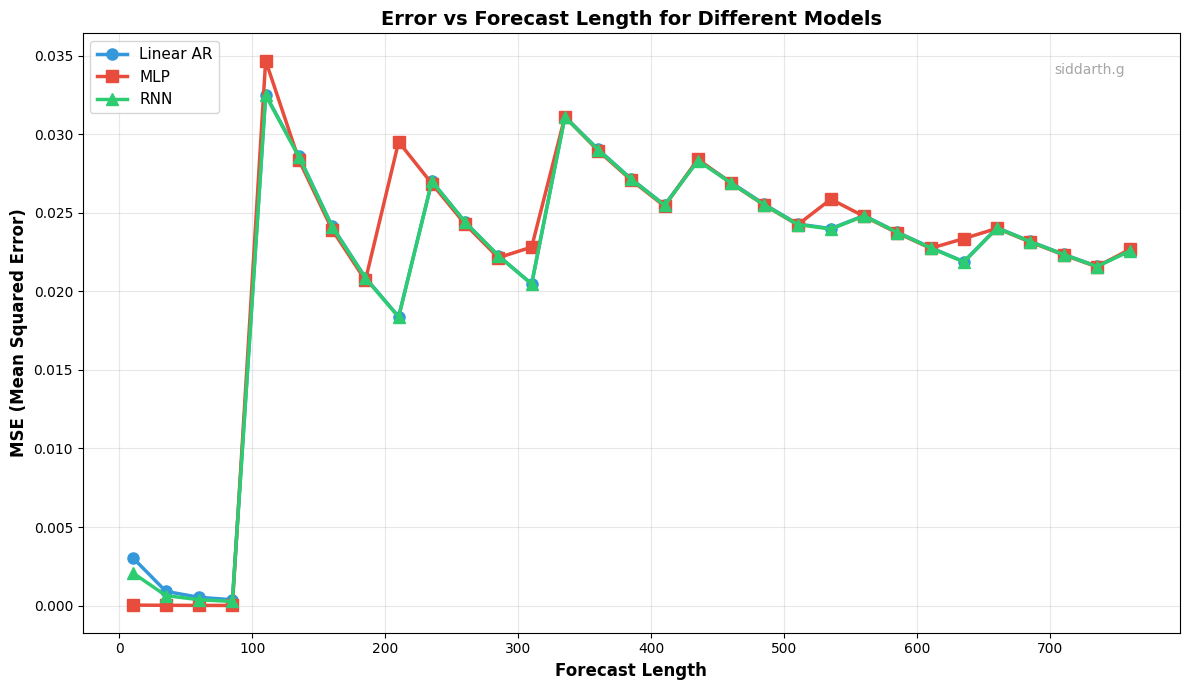


ERROR VS FORECAST LENGTH RESULTS

Forecast Length    Linear AR MSE      MLP MSE            RNN MSE           
------------------------------------------------------------------------
10                 0.003059           0.000034           0.002092          
35                 0.000906           0.000022           0.000639          
60                 0.000529           0.000014           0.000375          
85                 0.000373           0.000010           0.000266          
110                0.032520           0.034684           0.032478          
135                0.028602           0.028359           0.028559          
160                0.024134           0.023928           0.024099          
185                0.020872           0.020695           0.020843          
210                0.018388           0.029515           0.018362          
235                0.026999           0.026852           0.026993          
260                0.024405           0.024270          

In [123]:
# Error vs Forecast Length Analysis
print("="*60)
print("ERROR VS FORECAST LENGTH ANALYSIS")
print("="*60)

# Define different forecast lengths to test
forecast_lengths = np.arange(10, 761, 25)
test_start_idx = 197
tmp = 15

# Dictionary to store MSE for each model at each forecast length
error_vs_length = {
    'Linear_AR': [],
    'MLP': [],
    'RNN': []
}

print("\nComputing errors for different forecast lengths...")

for fl in tqdm(forecast_lengths, desc="Forecast lengths"):
    # Linear AR
    data_dict_linear = data_configs[best_linear_ar_history]
    initial_input_linear = data[test_start_idx:test_start_idx + best_linear_ar_history]
    ground_truth_linear = data[test_start_idx + best_linear_ar_history:test_start_idx + best_linear_ar_history + fl]
    
    forecast_linear = autoregressive_forecast_linear_ar(
        linear_ar_model, initial_input_linear, fl, best_linear_ar_history
    )
    mse_linear = mean_squared_error(ground_truth_linear, forecast_linear)
    error_vs_length['Linear_AR'].append(mse_linear)
    
    # MLP
    data_dict_mlp = data_configs[best_mlp_history]
    initial_input_mlp = data[test_start_idx-tmp:test_start_idx-tmp + best_mlp_history]
    ground_truth_mlp = data[test_start_idx-tmp + best_mlp_history:test_start_idx-tmp + best_mlp_history + fl]
    
    mlp_model.model.eval()
    forecast_mlp = autoregressive_forecast_mlp(
        mlp_model, initial_input_mlp, fl, best_mlp_history,
        data_dict_mlp['scaler_X'], data_dict_mlp['scaler_y']
    )
    mse_mlp = mean_squared_error(ground_truth_mlp, forecast_mlp)
    error_vs_length['MLP'].append(mse_mlp)
    
    # RNN
    data_dict_rnn = data_configs[best_rnn_history]
    initial_input_rnn = data[test_start_idx:test_start_idx + best_rnn_history]
    ground_truth_rnn = data[test_start_idx + best_rnn_history:test_start_idx + best_rnn_history + fl]
    
    vanilla_rnn_model.eval()
    forecast_rnn = autoregressive_forecast_rnn(
        vanilla_rnn_model, initial_input_rnn, fl, best_rnn_history,
        data_dict_rnn['scaler_X'], data_dict_rnn['scaler_y']
    )
    mse_rnn = mean_squared_error(ground_truth_rnn, forecast_rnn)
    error_vs_length['RNN'].append(mse_rnn)

# Create the plot
plt.figure(figsize=(12, 7))

plt.plot(forecast_lengths, error_vs_length['Linear_AR'], 
         marker='o', linewidth=2.5, markersize=8, label='Linear AR', color='#3498db')
plt.plot(forecast_lengths, error_vs_length['MLP'], 
         marker='s', linewidth=2.5, markersize=8, label='MLP', color='#e74c3c')
plt.plot(forecast_lengths, error_vs_length['RNN'], 
         marker='^', linewidth=2.5, markersize=8, label='RNN', color='#2ecc71')

plt.xlabel('Forecast Length', fontsize=12, fontweight='bold')
plt.ylabel('MSE (Mean Squared Error)', fontsize=12, fontweight='bold')
plt.title('Error vs Forecast Length for Different Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
add_username()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ERROR VS FORECAST LENGTH RESULTS")
print("="*60)
print(f"\n{'Forecast Length':<18} {'Linear AR MSE':<18} {'MLP MSE':<18} {'RNN MSE':<18}")
print("-"*72)
for i, fl in enumerate(forecast_lengths):
    print(f"{fl:<18} {error_vs_length['Linear_AR'][i]:<18.6f} {error_vs_length['MLP'][i]:<18.6f} {error_vs_length['RNN'][i]:<18.6f}")
print("="*72)